In [58]:
# добавим логгирование
from comet_ml import Experiment

# Создайте эксперимент с помощью вашего API ключа
experiment = Experiment(
    api_key='tZRw90ggp7Sqvv6KySBS0AXOq',
    project_name='project_3',
    workspace='valentinagurina',
)

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.com/valentinagurina/project-3/c2ca9d394df84bd3b1126d3422c2362c
COMET INFO:   Uploads:
COMET INFO:     environment details      : 1
COMET INFO:     filename                 : 1
COMET INFO:     git metadata             : 1
COMET INFO:     git-patch (uncompressed) : 1 (16.59 KB)
COMET INFO:     installed packages       : 1
COMET INFO:     notebook                 : 1
COMET INFO:     source_code              : 1
COMET INFO: 


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/valentinagurina/project-3/9a164f66667444d1b14536c490654e91



In [59]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# импортируем библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

# Загружаем специальный удобный инструмент для разделения датасета:
from sklearn.model_selection import train_test_split

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [60]:
# всегда фиксируйте RANDOM_SEED, чтобы ваши эксперименты были воспроизводимы!
RANDOM_SEED = 42

In [61]:
# зафиксируем версию пакетов, чтобы эксперименты были воспроизводимы:
!pip freeze > requirements.txt

# Изучение данных

### Рассмотрим данные предоставленные для соревнования 

In [62]:
# Подгрузим наши данные из соревнования

#DATA_DIR = '/kaggle/input/sf-booking/'
df_train = pd.read_csv('./hotels_train.csv') # датасет для обучения
df_test = pd.read_csv('./hotels_test.csv') # датасет для предсказания
sample_submission = pd.read_csv('./submission.csv') # самбмишн

In [63]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

In [64]:
df_train.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097


In [65]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               128935 non-null  object 
 1   additional_number_of_scoring                128935 non-null  int64  
 2   review_date                                 128935 non-null  object 
 3   average_score                               128935 non-null  float64
 4   hotel_name                                  128935 non-null  object 
 5   reviewer_nationality                        128935 non-null  object 
 6   negative_review                             128935 non-null  object 
 7   review_total_negative_word_counts           128935 non-null  int64  
 8   total_number_of_reviews                     128935 non-null  int64  
 9   positive_review                             128935 non-null  object 
 

In [66]:
df_test.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443


In [67]:
sample_submission.head(2)

,reviewer_score,id
0,8.502,488440
1,8.080,274649


In [68]:
sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   reviewer_score  128935 non-null  float64
 1   id              128935 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 2.0 MB


df_train - Тренировочная выборка состоит из 386803 наблюдений,
в ней содержится информация о результирующем значении - том значении, что мы хотим предстказать (reviewer_score) и 16 признаках (типов float64(4), int64(5), object(8))

df_test - Тестовая выборка состоит из 128935  наблюдений,
в ней отсутствует информация о reviewer_score. Количество признаков такое же, как и в тренировочной выборке 16 признаках 

sample_submission -  Выборка для представления результатов состоит из 128935  наблюдений reviewer_score и id наблюдений
На основании этой выборки мы будем оценивать качество полученной модели

In [69]:
#Перед объединением и дальнейшей работы с данными выполним проверку на наличие полных дубликатов

print('Количество дубликатов: {}'.format(df_train[df_train.duplicated()].shape[0]))
df_train = df_train.drop_duplicates()

Количество дубликатов: 307


_________________________________________________________________________________________________________________________________________

In [70]:
# ВАЖНО! дря корректной обработки признаков объединяем трейн и тест в один датасет
df_train['sample'] = 1 # помечаем где у нас трейн
df_test['sample'] = 0 # помечаем где у нас тест
df_test['reviewer_score'] = 0 # в тесте у нас нет значения reviewer_score, мы его должны предсказать, по этому пока просто заполняем нулями

#предложенный в бейзлайне не отработал, поэтому объединим с помощью concat
data = pd.concat([df_test, df_train],    # Combine vertically
                          ignore_index = True,
                         sort = False)

In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515431 non-null  object 
 1   additional_number_of_scoring                515431 non-null  int64  
 2   review_date                                 515431 non-null  object 
 3   average_score                               515431 non-null  float64
 4   hotel_name                                  515431 non-null  object 
 5   reviewer_nationality                        515431 non-null  object 
 6   negative_review                             515431 non-null  object 
 7   review_total_negative_word_counts           515431 non-null  int64  
 8   total_number_of_reviews                     515431 non-null  int64  
 9   positive_review                             515431 non-null  object 
 

In [72]:
#быстро проанализируем данные c ProfileReport и далее перейдем к более детальному анализу
from ydata_profiling import ProfileReport
profile = ProfileReport(data, title="BOOKING analitical preview")

#profile.to_file("BOOKING_analitical_preview.html")
#profile

Первоначальная версия датасета содержит 17 полей со следующей информацией:

hotel_address — адрес отеля;
review_date — дата, когда рецензент разместил соответствующий отзыв;
average_score — средний балл отеля, рассчитанный на основе последнего комментария за последний год;
hotel_name — название отеля;
reviewer_nationality — страна рецензента;
negative_review — отрицательный отзыв, который рецензент дал отелю;
review_total_negative_word_counts — общее количество слов в отрицательном отзыв;
positive_review — положительный отзыв, который рецензент дал отелю;
review_total_positive_word_counts — общее количество слов в положительном отзыве.
reviewer_score — оценка, которую рецензент поставил отелю на основе своего опыта;
total_number_of_reviews_reviewer_has_given — количество отзывов, которые рецензенты дали в прошлом;
total_number_of_reviews — общее количество действительных отзывов об отеле;
tags — теги, которые рецензент дал отелю;
days_since_review — количество дней между датой проверки и датой очистки;
additional_number_of_scoring — есть также некоторые гости, которые просто поставили оценку сервису, но не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.
lat — географическая широта отеля;
lng — географическая долгота отеля.

На основании первичного анализа сформулирую первоначальных план работ над признаками

* 'hotel_address' - 1493 уникальных названий, на 1 больше чем названий отелей)), выделилим из этого поля как страну и город нахождения отеля,

* 'additional_number_of_scoring' имеет высокую корреляцию с total_number_of_reviews поэтому оставим один из этих признаков, но надо проанализировать данные, чтобы выбрать какой оставить. на первый взгляд не понятен смысл данного признака, признак total_number_of_reviews более понятен

* 'review_date' - равномерно распределенный признак, 731 уникальное значение, может попробовать создать признак актуальности review, вычтем из максимальной даты дату отзыва и попробуем включить в модель,
       
* 'average_score'- числовой признак, без пропусков и нулей, будет использоваться в построении моделей, 

* 'hotel_name' - 1492 уникальных названий, без пропусков. Честно говоря, не знаю, что можно сделать с этим попробуем перевести данное поле в кол-во слов  и включить в модель, 

* 'reviewer_nationality'- 227 уникальных значений. Самые популярные страны это UK - 47,55% и USA = 6,87% из из всего числа наблюдений, из данного признака сформирую категориальных признак, который будет выводить топ 10 национальностей, а прочие заменит на "other",

* 'negative_review'- на основании данного признака посчитаю кол-во слов в отзыве и удалю, 

* 'review_total_negative_word_counts' - у поля какие-то странные значения, пересчитаю самостоятельно на основании признака 'negative_review', этот удалю,

* 'total_number_of_reviews' имеет высокую корреляцию с 'additional_number_of_scoring' поэтому оставим один из этих признаков

* 'positive_review',  на основании данного признака посчитаю кол-во слов в отзыве и удалю, 

* 'review_total_positive_word_counts' - у поля какие-то странные значения, пересчитаю самостоятельно на основании 'positive_review' , этот удалю,

* 'total_number_of_reviews_reviewer_has_given' числовой признак, без пропусков и нулей, будет использоваться в построении моделей, но надо проанализировать наличие выбросов - макс значение 354, а 95ый квартиль - 26,  

* 'tags' - проанализирую и разобъю теги на категории, а далее закодируем,
       
* 'days_since_review'-  переведу в числовой признак и включим в модель,

* 'lat' - буду использовать, но надо заполнить пустые значения, попробуем сделать это на основании того, в какой стране/городе находится отель и задать ему нужные параметры 

* 'lng'- буду использовать, но надо заполнить пустые значения, , попробуем сделать это на основании того, в какой стране/городе находится отель и задать ему нужные параметры 

In [73]:
# посчитала доп информацию по признаку hotel_name
UK_counts = round(data[data['reviewer_nationality'] == ' United Kingdom ']['reviewer_nationality'].count()/data['reviewer_nationality'].count()*100,2)
US_counts = round(data[data['reviewer_nationality'] == ' United States of America ']['reviewer_nationality'].count()/data['reviewer_nationality'].count()*100,2)

display(UK_counts, US_counts )

47.57

6.87

In [74]:
data.nunique(dropna=False)

hotel_address                                   1493
additional_number_of_scoring                     480
review_date                                      731
average_score                                     34
hotel_name                                      1492
reviewer_nationality                             227
negative_review                               330011
review_total_negative_word_counts                402
total_number_of_reviews                         1142
positive_review                               412601
review_total_positive_word_counts                365
total_number_of_reviews_reviewer_has_given       198
tags                                           55242
days_since_review                                731
lat                                             1473
lng                                             1473
sample                                             2
reviewer_score                                    38
dtype: int64

_______________________________________________________________

## Первичная очистка данных
(повторю данный пункт после детальной обработки признаков)

In [75]:
#ранее мы видели где есть пропуски, подтверждаем их наличие только в 2 признаках
#проверка на наличие пропусков
cols_null_percent = data.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

lat    0.634032
lng    0.634032
dtype: float64

Разберемся с пропусками при детальном анализе

In [76]:
#проверка на наличие неинформативных признаков

#список неинформативных признаков
low_information_cols = [] 

#цикл по всем столбцам
for col in data.columns:
    #наибольшая относительная частота в признаке
    top_freq = data[col].value_counts(normalize=True).max()
    #доля уникальных значений от размера признака
    nunique_ratio = data[col].nunique() / data[col].count()
    # сравниваем наибольшую частоту с порогом
    if top_freq > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(top_freq*100, 2)}% одинаковых значений')
    # сравниваем долю уникальных значений с порогом
    if nunique_ratio > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(nunique_ratio*100, 2)}% уникальных значений')
        
low_information_cols   

[]

__________________

## Рассмотрим каждый из признаков по отдельности

#### 'hotel_address'

In [77]:
#из адреса выберем город нахождения отеля
data['city_hotel'] = data['hotel_address'].apply(lambda x: x.split(' ')[-5] if x.split(' ')[-1] == 'Kingdom' else  x.split(' ')[-2])


[Text(0, 0, 'Milan'),
 Text(1, 0, 'Amsterdam'),
 Text(2, 0, 'Barcelona'),
 Text(3, 0, 'London'),
 Text(4, 0, 'Paris'),
 Text(5, 0, 'Vienna')]

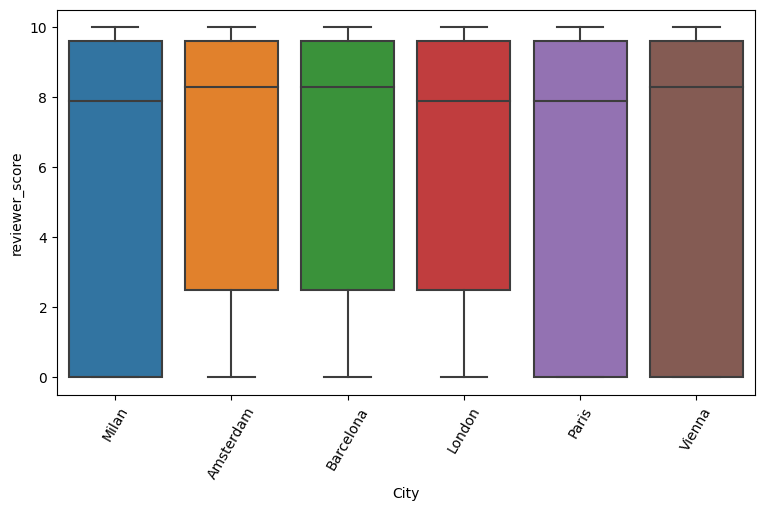

In [78]:
fig = plt.subplots(figsize=(9,5))

boxplot1 = sns.boxplot(data=data, x="city_hotel", y="reviewer_score")
boxplot1.set_xlabel('City')
boxplot1.set_ylabel('reviewer_score')
boxplot1.set_xticklabels(boxplot1.get_xticklabels(), rotation=60)

In [79]:
data.groupby('city_hotel')['reviewer_score'].agg(['mean', 'median', 'count'])

,mean,median,count
city_hotel,,,
Amsterdam,6.350886,8.3,57212
Barcelona,6.418190,8.3,60149
London,6.246682,7.9,262300
Milan,6.261603,7.9,37206
Paris,6.291130,7.9,59626
Vienna,6.408624,8.3,38938


В рамках промежуточных моделей исключила признак страны отелей, из-за высокой коррелации с большим кол-вом других признаков, а также отсутствием существенного эффекта на интересующую переменную. Оставлен только признак города, где находятся отели. Больше всего отелей расположены в Лондоне. Медианные оценки отелей в Амстердаме и Барселоне, Вене выше, чем в других городах. Средние оценки отличаются несущественно.


___________

#### 'additional_number_of_scoring', 'total_number_of_reviews'

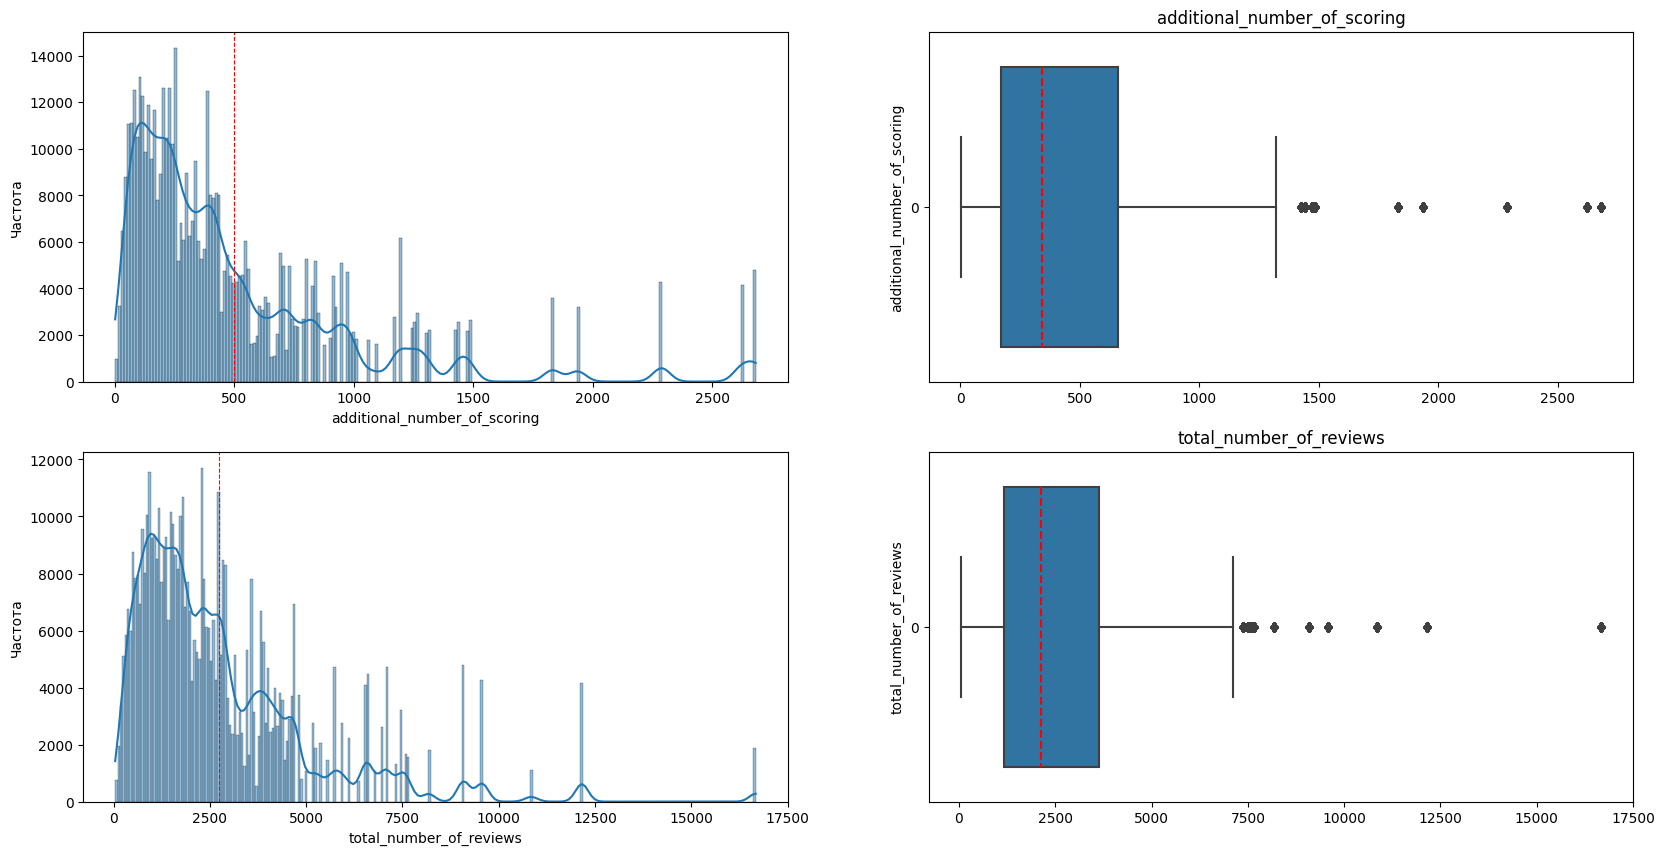

In [80]:
#визуализируем распределение признаков

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

histplot1 = sns.histplot(data['additional_number_of_scoring'], kde=True, ax=axes[0,0])

histplot1.set(xlabel='additional_number_of_scoring', ylabel='Частота')
histplot1.axvline(data['additional_number_of_scoring'].mean(), color='red', linestyle='--', linewidth=0.8)

boxplot1 = sns.boxplot(data['additional_number_of_scoring'], ax=axes[0,1], orient='h', medianprops={"color": "red", "linestyle": '--'})
boxplot1.set(ylabel='additional_number_of_scoring')
boxplot1.set_title('additional_number_of_scoring')


histplot2 = sns.histplot(data['total_number_of_reviews'], kde=True, ax=axes[1,0])

histplot2.set(xlabel='total_number_of_reviews', ylabel='Частота')
histplot2.axvline(data['total_number_of_reviews'].mean(), color='red', linestyle='--', linewidth=0.8)

boxplot2 = sns.boxplot(data['total_number_of_reviews'], ax=axes[1,1], orient='h', medianprops={"color": "red", "linestyle": '--'})
boxplot2.set(ylabel='total_number_of_reviews')
boxplot2.set_title('total_number_of_reviews')

plt.show()

Эти два признака имеют высокую корреляцию, поэтому оставим один из них. Для меня логически более понятен признак total_number_of_reviews — общее количество действительных отзывов об отеле.
его и оставим, признак additional_number_of_scoring будет удален. Более того, total_number_of_reviews визуально имеет меньше выбросов, поработаем над ними.

Тк данный признак не распределен нормально (распределение похоже на логнормальное), то можно преобразовать его через логарифм и далее использовать логарифм от данного признака

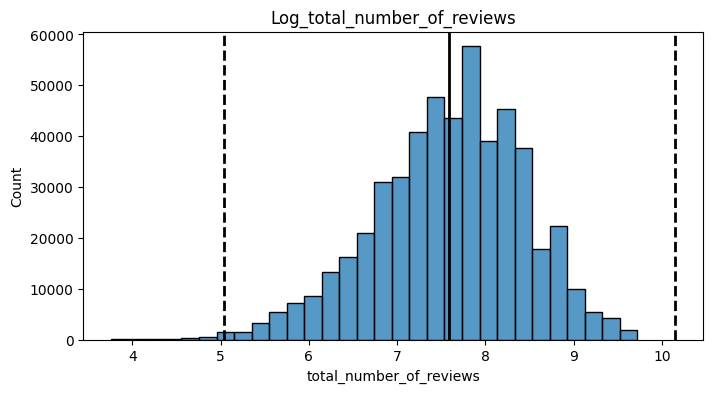

In [25]:
#визуализируем 
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
log_num_reviews = np.log(data['total_number_of_reviews'])
histplot = sns.histplot(log_num_reviews, bins=30, ax=ax)
histplot.axvline(log_num_reviews.mean(), color='k', lw=2)
histplot.axvline(log_num_reviews.mean()+ 3 * log_num_reviews.std(), color='k', ls='--', lw=2)
histplot.axvline(log_num_reviews.mean()- 3 * log_num_reviews.std(), color='k', ls='--', lw=2)
histplot.set_title('Log_total_number_of_reviews');

После преобразования видим, что распределение не симметрично, левый хвост боьше правого.
Для поиска выбросов применим метод z-отклонений, модифицировав его на ручной ввод кол-ва сигм

In [81]:
#метода z-отклонения
def outliers_z_score_mod(data, feature, log_scale=False, left = 3, right = 3):
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - left * sigma
    upper_bound = mu + right * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    
    return outliers, cleaned

In [82]:
#тк распределение не симметрично, то мы дали левому хвосту послабление на 4 сигмы (если взять 5 сигм, то выбросов не будет)
outliers, cleaned = outliers_z_score_mod(data, 'total_number_of_reviews', log_scale=True, left = 4, right = 3)
print(f'Число выбросов по методу z-отклонения: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')
print("Кол-во уникальный выбросов:", outliers['total_number_of_reviews'].nunique())

Число выбросов по методу z-отклонения: 236
Результирующее число записей: 515195
Кол-во уникальный выбросов: 9


In [83]:
# заменим выбросы на минимальное значение очищенных данных

outliers_list = list(outliers['total_number_of_reviews'].unique())
min_value = cleaned[['total_number_of_reviews']].min()
print(outliers_list, min_value)

def change_outliers (data):
    if data in outliers_list:
        return min_value['total_number_of_reviews']
    else:
        return data

data['total_number_of_reviews_upd'] = data ['total_number_of_reviews'].apply(change_outliers)


[59, 64, 60, 49, 51, 43, 61, 54, 45] total_number_of_reviews    66
dtype: int64


In [84]:
#создадим новый признак - логарифм от признака  total_number_of_reviews_upd
data['Log_total_number_of_reviews'] = np.log(data['total_number_of_reviews_upd'])
data['Log_total_number_of_reviews'] 

#удалим вспомогательную колонку
data = data.drop(['total_number_of_reviews_upd'], axis=1)

In [85]:
#удалим  признаки
data = data.drop(['total_number_of_reviews','additional_number_of_scoring'], axis=1)

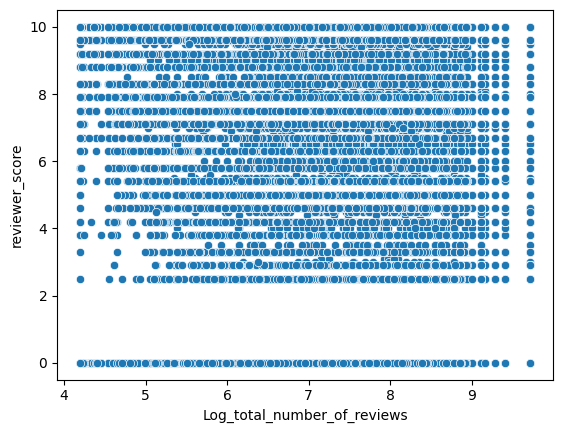

In [31]:
#посмотрим есть ли визуально зависимость нашей искомой переменной от признака

fig= sns.scatterplot(data=data, x="Log_total_number_of_reviews", y="reviewer_score")

Какая-то зависимость присутствует, чем выше значения Log_total_number_of_reviews, тем выше reviewer_score (точки в правом верхнем углу лежат кучнее тех, что в левом нижнем)

#### 'review_date'

In [86]:
#переведем в нужный формат данные, посчитаем показатель, и сохраним новый признак
data['review_date'] = pd.to_datetime(data['review_date'], dayfirst=False)
max_date = data['review_date'].max()
data['actuality_review'] = max_date-data['review_date']
data['actuality_review'] = pd.to_numeric(data['actuality_review'].dt.days, downcast='integer')

Признаки года, даты, дня недели не оказали существенного положительного влияния на модель, поэтому не выводятся

Text(0.5, 1.0, 'actuality_review')

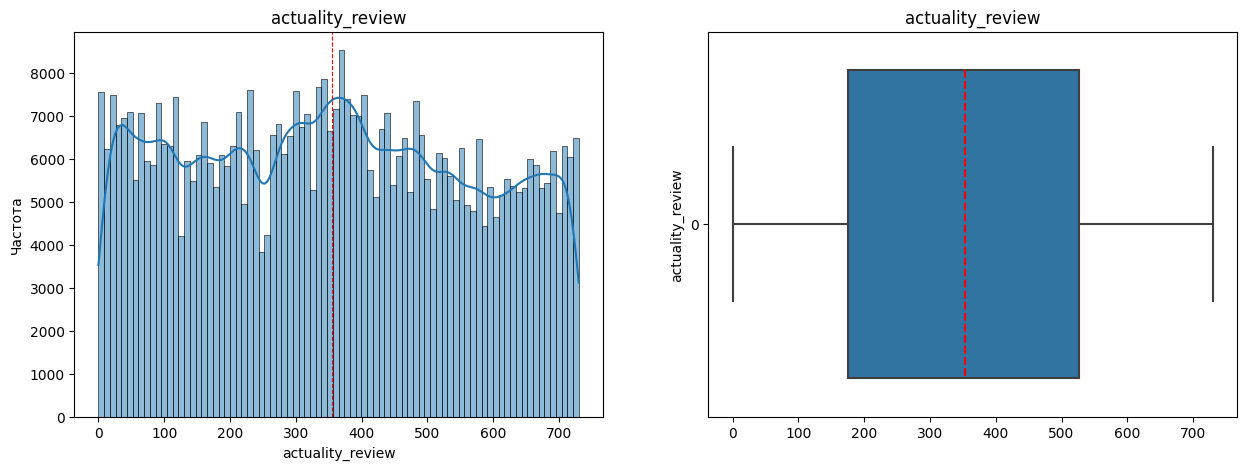

In [33]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['actuality_review'], kde=True, ax=axes[0])

axes[0].set(xlabel='actuality_review', ylabel='Частота')
axes[0].set_title('actuality_review')
axes[0].axvline(data['actuality_review'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['actuality_review'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='actuality_review')
axes[1].set_title('actuality_review')

In [87]:
#добавим признак месяца года
data['month_of_review'] = pd.DatetimeIndex(data['review_date']).month
 

[Text(0, 0, '1'),
 Text(1, 0, '2'),
 Text(2, 0, '3'),
 Text(3, 0, '4'),
 Text(4, 0, '5'),
 Text(5, 0, '6'),
 Text(6, 0, '7'),
 Text(7, 0, '8'),
 Text(8, 0, '9'),
 Text(9, 0, '10'),
 Text(10, 0, '11'),
 Text(11, 0, '12')]

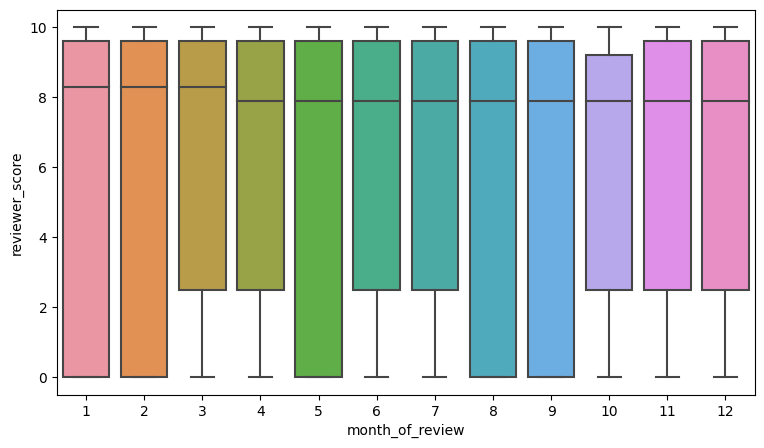

In [35]:
fig = plt.subplots(figsize=(9,5))

boxplot1 = sns.boxplot(data=data, x="month_of_review", y="reviewer_score")
boxplot1.set_xlabel('month_of_review')
boxplot1.set_ylabel('reviewer_score')
boxplot1.set_xticklabels(boxplot1.get_xticklabels())

In [88]:
data.groupby('month_of_review')['reviewer_score'].agg(['mean', 'median', 'count'])

,mean,median,count
month_of_review,,,
1,6.340859,8.3,42133
2,6.390874,8.3,38352
3,6.374461,8.3,41090
4,6.333693,7.9,42872
5,6.255543,7.9,46470
6,6.300273,7.9,42877
7,6.279229,7.9,49291
8,6.292872,7.9,50632
9,6.213177,7.9,42369


Зафиксируем, что медиана оценок в 1кв (и соответственно в месяцах 1,2,3) выше, чем в других месяцах/кварталах. При этом бинарный признак 1ого квартала не улучшил модель, поэтому его не рассматриваю

In [89]:
#удалим  признаки
data = data.drop(['review_date'], axis=1)

_____________

#### 'average_score'

Text(0.5, 1.0, 'average_score')

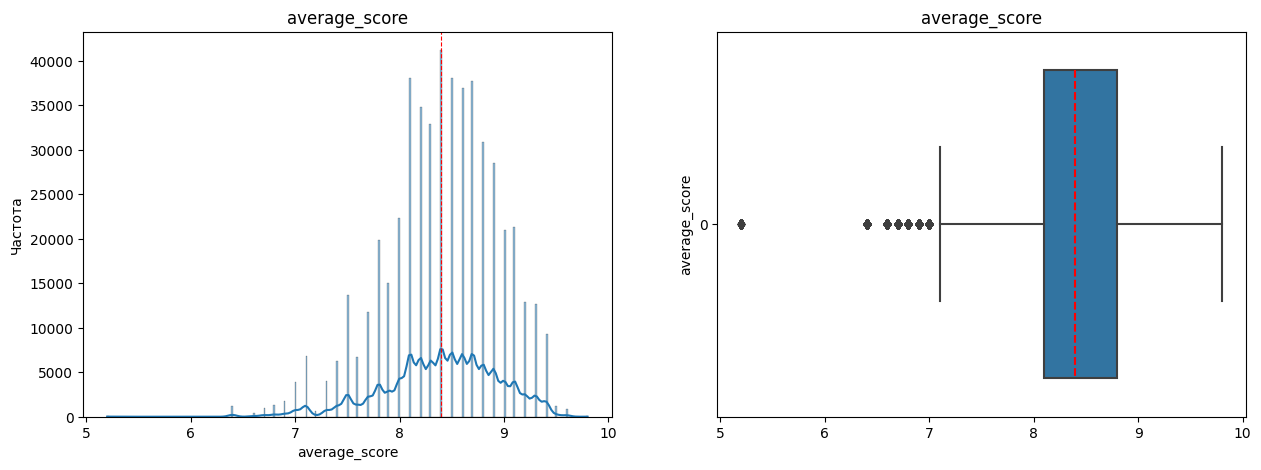

In [90]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['average_score'], kde=True, ax=axes[0])

axes[0].set(xlabel='average_score', ylabel='Частота')
axes[0].set_title('average_score')
axes[0].axvline(data['average_score'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['average_score'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='average_score')
axes[1].set_title('average_score')

In [91]:
#Предлагаю заменить отдельно-стоящие наблюдения (65 шт) - 5.2 на близлежащие к ним - 6.4. Т.к. можно предположить данные наблюдения являются выбросами
data['average_score'] = data['average_score'].apply(lambda x: 6.4 if x == 5.2 else x )

--------

#### 'hotel_name' 

In [92]:
#создадим новый признак - длину названия отеля
data['hotel_name_count'] = data['hotel_name'].str.split().apply(len)


<Axes: xlabel='hotel_name_count', ylabel='reviewer_score'>

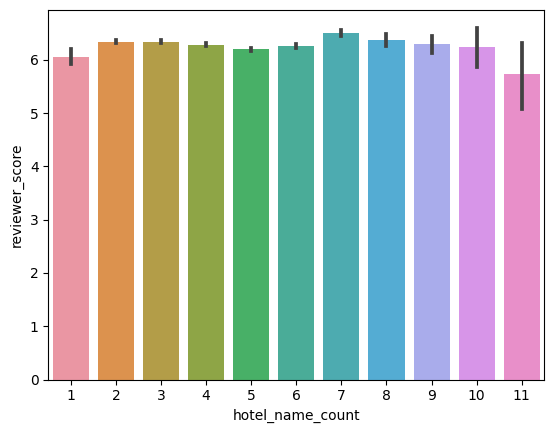

In [47]:
fig = sns.barplot(data=data, x="hotel_name_count", y="reviewer_score")
fig

In [93]:
data.groupby('hotel_name_count')['reviewer_score'].agg(['mean', 'median', 'count'])

,mean,median,count
hotel_name_count,,,
1,6.056883,7.5,2477
2,6.335272,8.3,74415
3,6.341597,8.3,142365
4,6.284123,7.9,136422
5,6.198337,7.9,96326
6,6.255876,7.9,36073
7,6.493805,8.3,18901
8,6.373007,8.3,5431
9,6.288527,8.3,2397


In [94]:
#также предлагаю создать новый признак, что отель входит в топ сетевых отелей европы (список взяла с первой ссылки в интернете)
data['hotel_name'] =  data['hotel_name'].str.lower()

def find_top_hotels (data):
    top_hotels_list = ['hilton', 'marriott','hyatt','sheraton','wyndham', 'accor','carlson', 'choice', 'holiday', 'western']
    words = data.split()
    count = 0
    for word in words:
        if word in top_hotels_list:
            return 1
        else: return 0

data['top_hotels_flag'] = data['hotel_name'].apply(find_top_hotels)

data['top_hotels_flag'].groupby(data['top_hotels_flag']).count()

top_hotels_flag
0    481757
1     33674
Name: top_hotels_flag, dtype: int64

<Axes: xlabel='top_hotels_flag', ylabel='reviewer_score'>

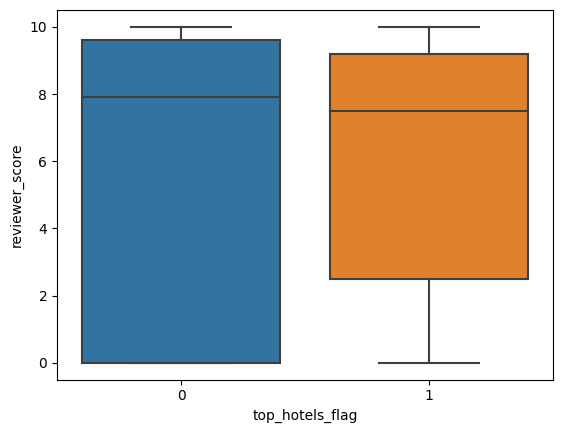

In [95]:
fig = sns.boxplot(data=data, x="top_hotels_flag", y="reviewer_score")
fig

In [96]:
data.groupby('top_hotels_flag')['reviewer_score'].agg(['mean', 'median', 'count'])

,mean,median,count
top_hotels_flag,,,
0,6.311755,7.9,481757
1,6.081547,7.5,33674


Результат несколько неожиданные - вхождение отеля в список топ сетевых отелей несущественно, но снижает оценку пользователей.
При этом 

In [97]:
data = data.drop(['hotel_name'], axis=1)

--------

#### 'reviewer_nationality'

In [98]:
#выделим в качестве признака вхождение в топ 10 национальностей тех, кто оставляет отзывы
data['reviewer_nationality'] = data['reviewer_nationality'].apply(lambda x: x.strip())
top_nationalities = data['reviewer_nationality'].groupby(data['reviewer_nationality']).count().sort_values(ascending=False).head(10)

data['top_reviewer_nationality'] = data['reviewer_nationality'].apply(lambda x: x if x in top_nationalities else 'Other' )
top_nationalities

reviewer_nationality
United Kingdom              245165
United States of America     35390
Australia                    21663
Ireland                      14820
United Arab Emirates         10230
Saudi Arabia                  8945
Netherlands                   8762
Switzerland                   8672
Germany                       7936
Canada                        7887
Name: reviewer_nationality, dtype: int64

<Axes: xlabel='top_reviewer_nationality', ylabel='reviewer_score'>

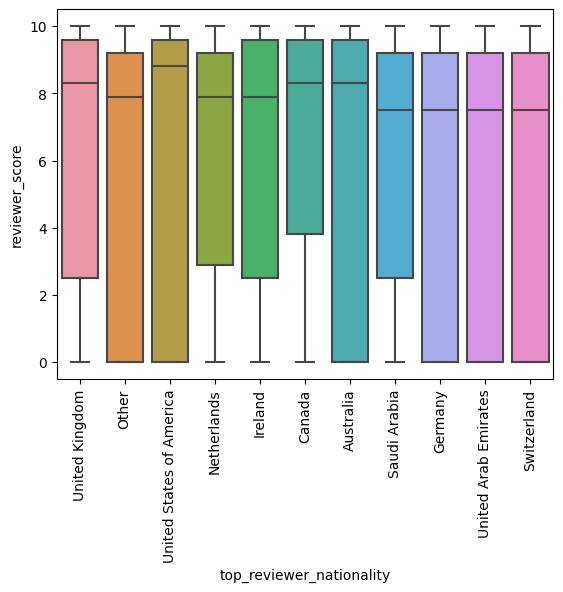

In [55]:
fig = sns.boxplot(data=data, x="top_reviewer_nationality", y="reviewer_score")
fig.set_xticklabels(fig.get_xticklabels(), rotation=90)
fig

<Axes: xlabel='reviewer_from_ESC', ylabel='reviewer_score'>

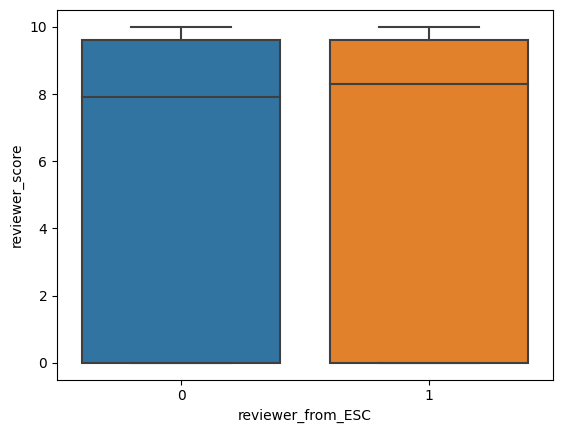

In [99]:
#создадим признак, который указывает о том, что ревьюер из США,Канады или Австравлии

data['reviewer_from_ESC'] = data['top_reviewer_nationality'].apply(lambda x: 1 if x == 'United States of America' or x== 'Australia' or x =='Canada' else 0 )

fig = sns.boxplot(data=data, x="reviewer_from_ESC", y="reviewer_score")
fig

Отметим, что ревьюеры из США, Канады и Австралии склонны к выставлению более высоких оценок (может это связано с тем, что они путешествуют издалека (те в анализе только европейские отели) и в рамках путешествим останавливаются в более дорогих и качественных отелях!?)

<Axes: xlabel='country_hotel_nationality', ylabel='reviewer_score'>

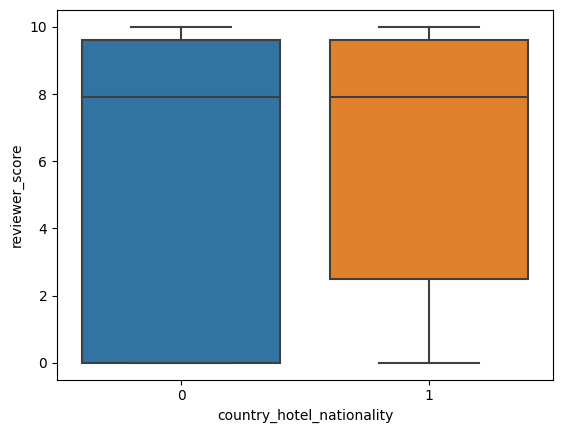

In [100]:
#cоздадим признак соотвествия страны отеля и места жительства интервьюера

# признак страны нужен для его составления , поэтому сделаем его и удалим после
#из адреса выберем страну нахождения отеля
data['country_hotel'] = data['hotel_address'].apply(lambda x: x.split(' ')[-1] if x.split(' ')[-1]  else 'NA')
#тк из всех возможных Kingdom в датасете речь идет о UK
data['country_hotel'] = data['country_hotel'].replace(['Kingdom'],'United Kingdom')
data['hotel_address'].groupby(data['country_hotel']).count()




data['country_hotel_nationality'] = data['country_hotel'] == data['reviewer_nationality']
data['country_hotel_nationality'] = data['country_hotel_nationality'].apply(lambda x: 1 if x ==True else 0)

fig = sns.boxplot(data=data, x="country_hotel_nationality", y="reviewer_score")
fig

Каких-то видимых различий по данному признаку не наблюдается

In [101]:
data = data.drop(['reviewer_nationality', 'country_hotel'], axis=1)

----

#### negative_review 
#### review_total_negative_word_counts
#### positive_review
#### review_total_positive_word_counts

In [102]:
#изучим самые популярные негативные отзывы
data['negative_review'] = data['negative_review'].str.lower()
data['negative_review'] = data['negative_review'].str.strip()
negative_review_top = data['negative_review'].groupby(data['negative_review']).count().sort_values(ascending=False).head(40)
negative_review_top

negative_review
no negative                  127816
nothing                       21177
n a                            1815
none                           1501
                                849
nothing really                  655
small room                      570
breakfast                       545
all good                        544
no complaints                   523
location                        501
nothing at all                  466
everything                      419
nothing to dislike              373
price                           348
nil                             332
small rooms                     307
everything was perfect          276
na                              272
can t think of anything         250
leaving                         244
absolutely nothing              242
everything was great            222
expensive                       206
nothing to complain about       205
room size                       200
no                              200
very small r

In [128]:
#Видим, что многие из отзывов, фактически НЕ являются негативными. попробуем с ними поработать. создадим флаг их наличия в отзыве
def find_no_neg_words (data):

    no_neg_words_list = ['no negative','nothing','n a', 'none',' ','nothing really','all good','no complaints', 'nothing at all', 'nothing to dislike', 'nil','everything was perfect',
                         'na','can t think of anything', 'absolutely nothing', 'everything was great', 'no', 'nothing not to like','nothing to complain about','nothing all good','having to leave'
                         'not much','i liked everything','non','nothing it was perfect','everything was good','liked everything','nothing in particular','no complaints at all','nothing to report',
                         'no negatives','no complaints at all','nothing everything was perfect','having to leave','nothing everything was great','all was good','nothing everything was great',
                         'not applicable','everything was fine','it was all good','loved everything','there was nothing we didn t like',''
                         ]
    data = data.strip()
    if data in no_neg_words_list:
        return 1
    else: return 0



data['no_negative_words_flag'] = data['negative_review'].apply(find_no_neg_words)

# c учетом данной корректировки пересчитаем признак длины негативного отзыва
data['negative_review_clean_count'] = np.where(data['no_negative_words_flag']==1, 0, data['negative_review'].str.split().apply(len))

Text(0.5, 1.0, 'negative_review_clean_count')

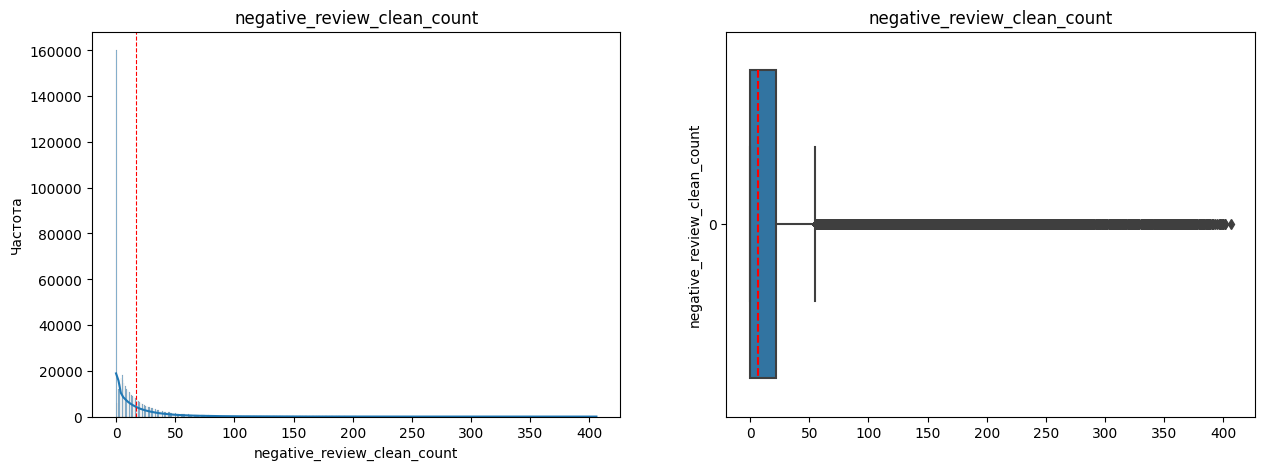

In [130]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['negative_review_clean_count'], kde=True, ax=axes[0])

axes[0].set(xlabel='negative_review_clean_count', ylabel='Частота')
axes[0].set_title('negative_review_clean_count')
axes[0].axvline(data['negative_review_clean_count'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['negative_review_clean_count'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='negative_review_clean_count')
axes[1].set_title('negative_review_clean_count')

In [131]:
#изучим самые популярные позитивные отзывы
data['positive_review'] = data['positive_review'].str.lower()
data['positive_review'] = data['positive_review'].str.strip()
positive_review_top = data['positive_review'].groupby(data['positive_review']).count().sort_values(ascending=False).head(30)


In [105]:
#Видим, что многие из отзывов, фактически НЕ являются позитивными. попробуем с ними поработать. создадим флаг их наличия в отзыве
def find_no_pos_words (data):

    no_pos_words_list = ['no positive','nothing','n a', 'none','nil',
                         'na', 'no', 'non'
                         ]
    data = data.strip()
    if data in no_pos_words_list:
        return 1
    else: return 0



data['no_positive_words_flag'] = data['positive_review'].apply(find_no_pos_words)

# c учетом данной корректировки пересчитаем признак длины негативного отзыва
data['positive_review_clean_count'] = np.where(data['no_positive_words_flag']==1, 0, data['positive_review'].str.split().apply(len))

Text(0.5, 1.0, 'positive_review_clean_count')

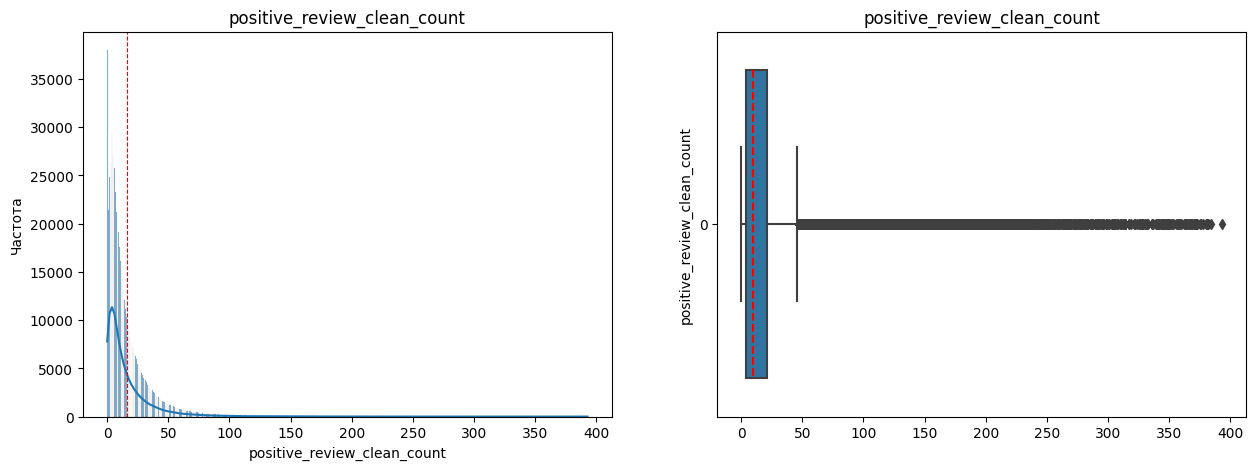

In [585]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['positive_review_clean_count'], kde=True, ax=axes[0])

axes[0].set(xlabel='positive_review_clean_count', ylabel='Частота')
axes[0].set_title('positive_review_clean_count')
axes[0].axvline(data['positive_review_clean_count'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['positive_review_clean_count'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='positive_review_clean_count')
axes[1].set_title('positive_review_clean_count')

In [134]:
# также на основании обновленных признаков можно создать новый признак: соотношение длины положит и отрицательного отзыва, логика в нем: что чем ниже/выше оценка - тем больше будет слов в отрицательном
# положительном отзыве

data['pos_neg_ratio'] = data['positive_review_clean_count']/(data['negative_review_clean_count']+1)

Text(0.5, 1.0, 'pos_neg_ratio')

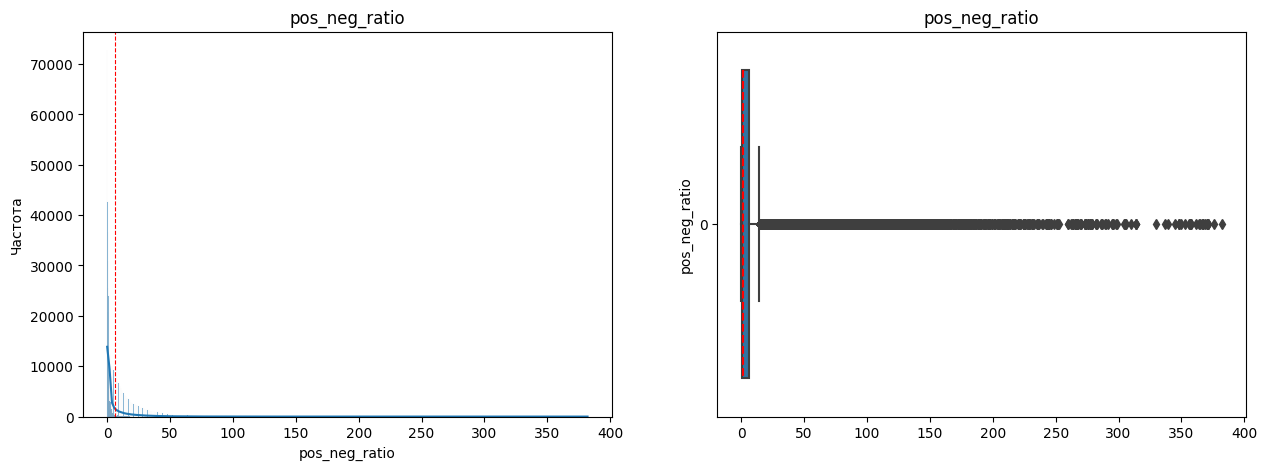

In [135]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['pos_neg_ratio'], kde=True, ax=axes[0])

axes[0].set(xlabel='pos_neg_ratio', ylabel='Частота')
axes[0].set_title('pos_neg_ratio')
axes[0].axvline(data['pos_neg_ratio'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['pos_neg_ratio'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='pos_neg_ratio')
axes[1].set_title('pos_neg_ratio')

In [136]:
def count_pos_word (data):

    positive_words_list = ['great','good','perfect', 'excellent','perfect','nice','lovely',
                           'comfortable', 'very', 'clean', 'friendly','pleasant', 'helpful','kind','homely','beautiful','delightful',
                           'grateful','graceful','glad', 'happy','thankful','wonderful']
    words = data.split()
    count = 0
    for word in words:
        if word in positive_words_list:
            count +=1
    return count

data['positive_words_count'] = data['positive_review'].apply(count_pos_word)

Text(0.5, 1.0, 'positive_words_count')

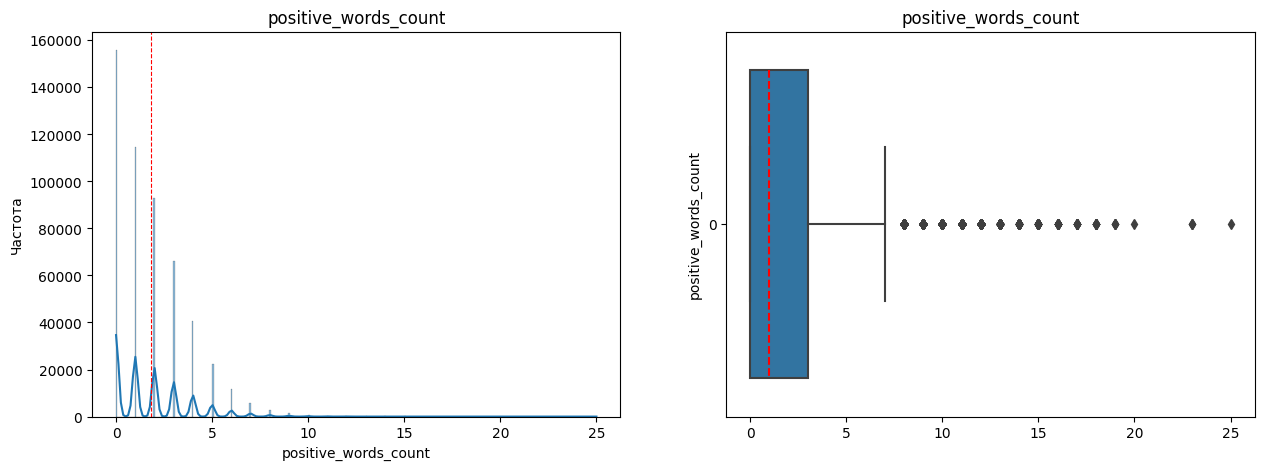

In [137]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['positive_words_count'], kde=True, ax=axes[0])

axes[0].set(xlabel='positive_words_count', ylabel='Частота')
axes[0].set_title('positive_words_count')
axes[0].axvline(data['positive_words_count'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['positive_words_count'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='positive_words_count')
axes[1].set_title('positive_words_count')

In [140]:
def count_neg_word (data):

    negative_words_list = ['dislike','expensive','small', 'size','bad','noise', 'no']
    words = data.split()
    count = 0
    for word in words:
        if word in negative_words_list:
            count +=1
    return count

data['negative_words_count'] = data['negative_review'].apply(count_neg_word)

In [141]:
data['negative_words_count'].groupby(data['negative_words_count']).count()

negative_words_count
0     262485
1     223412
2      21545
3       5579
4       1574
5        503
6        193
7         74
8         27
9         22
10         5
11         7
12         4
16         1
Name: negative_words_count, dtype: int64

In [143]:
data = data.drop([ 'negative_review', 'review_total_negative_word_counts','positive_review',
       'review_total_positive_word_counts'], axis=1)

Text(0, 0.5, 'reviewer_score')

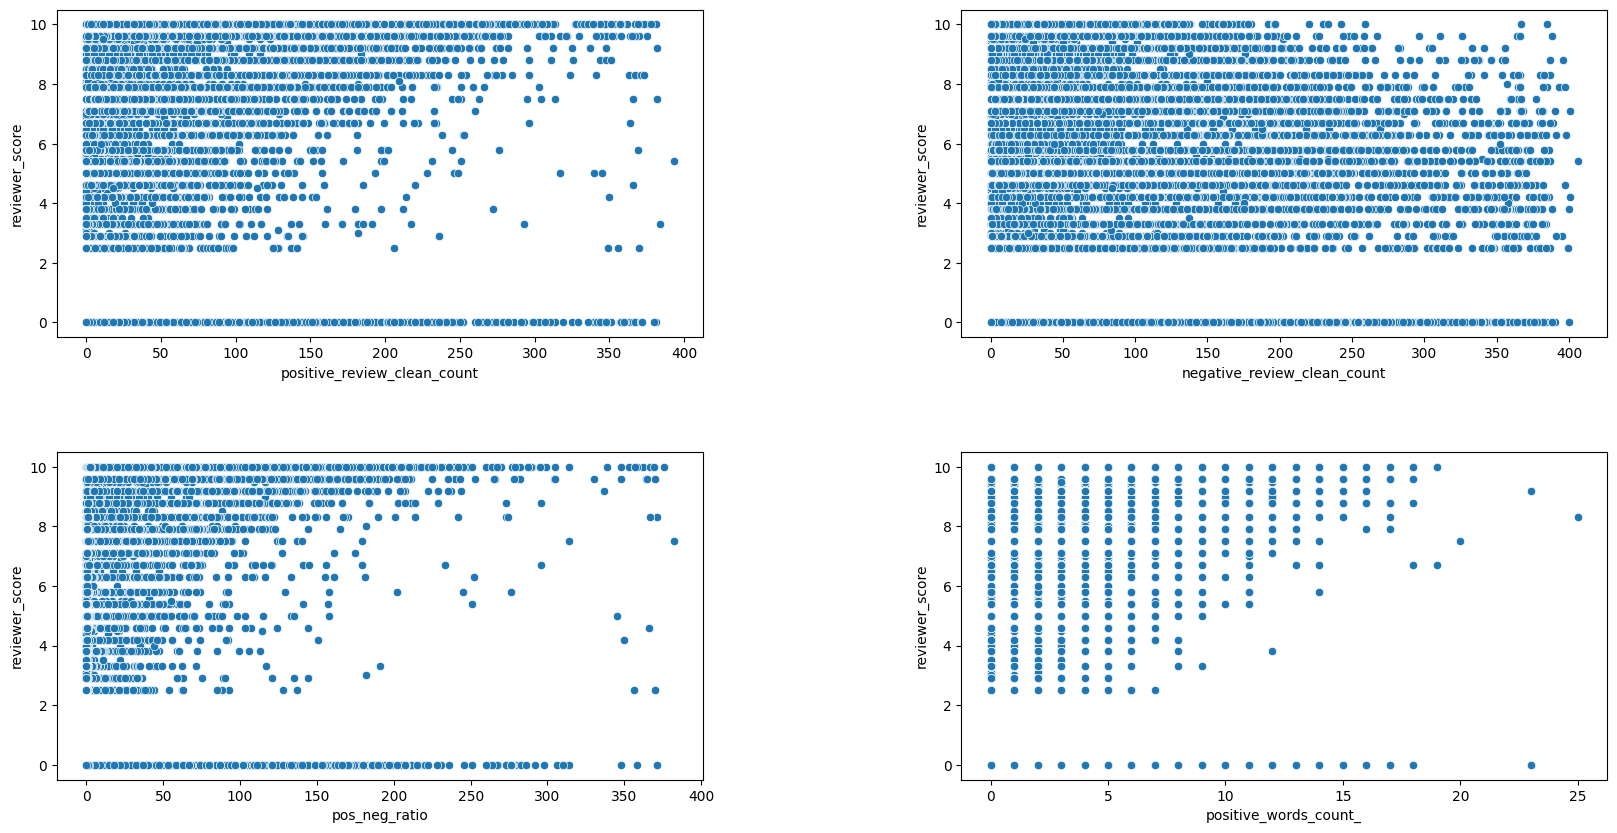

In [144]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))
plt.subplots_adjust(hspace=.35, wspace=.4)

scatterplot1 = sns.scatterplot(data=data, x="positive_review_clean_count", y="reviewer_score", ax=axes[0,0])
scatterplot1.set_xlabel('positive_review_clean_count')
scatterplot1.set_ylabel('reviewer_score')

scatterplot2 = sns.scatterplot(data=data, x="negative_review_clean_count", y="reviewer_score", ax=axes[0,1])
scatterplot2.set_xlabel('negative_review_clean_count')
scatterplot2.set_ylabel('reviewer_score')

scatterplot3 = sns.scatterplot(data=data, x="pos_neg_ratio", y="reviewer_score", ax=axes[1,0])
scatterplot3.set_xlabel('pos_neg_ratio')
scatterplot3.set_ylabel('reviewer_score')

scatterplot4 = sns.scatterplot(data=data, x="positive_words_count", y="reviewer_score", ax=axes[1,1])
scatterplot4.set_xlabel('positive_words_count_')
scatterplot4.set_ylabel('reviewer_score')


Очевидно, что зависимость переменных существует

___________________________

#### 'total_number_of_reviews_reviewer_has_given'

Text(0.5, 1.0, 'total_number_of_reviews_reviewer_has_given')

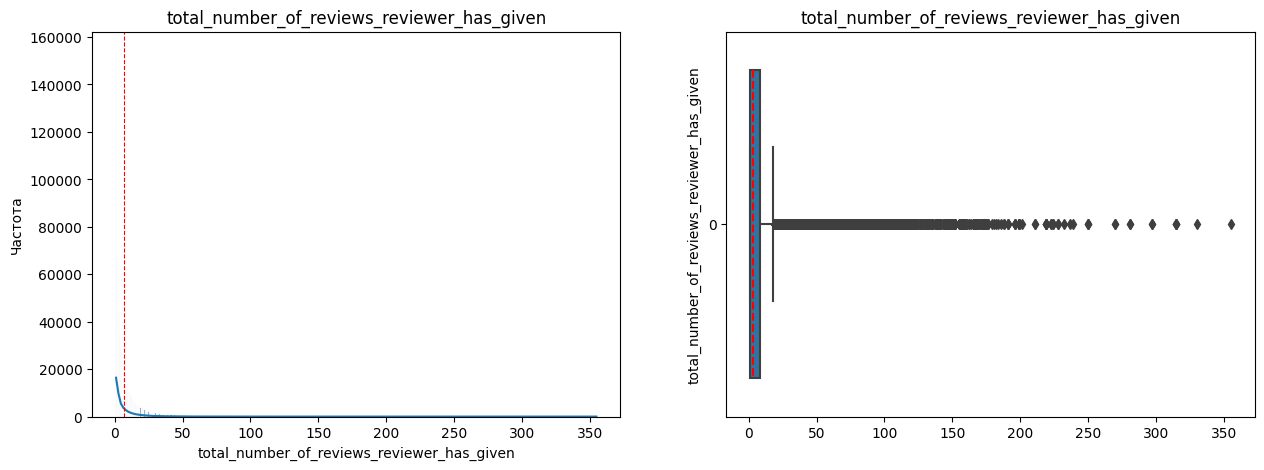

In [597]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['total_number_of_reviews_reviewer_has_given'], kde=True, ax=axes[0])

axes[0].set(xlabel='total_number_of_reviews_reviewer_has_given', ylabel='Частота')
axes[0].set_title('total_number_of_reviews_reviewer_has_given')
axes[0].axvline(data['total_number_of_reviews_reviewer_has_given'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['total_number_of_reviews_reviewer_has_given'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='total_number_of_reviews_reviewer_has_given')
axes[1].set_title('total_number_of_reviews_reviewer_has_given')

In [146]:
# для нормализации, стандартизации
from sklearn import preprocessing

# инициализируем нормализатор RobustScaler
r_scaler = preprocessing.RobustScaler()

# кодируем исходный датасет
data['total_num_reviews_has_given_norm']  = r_scaler.fit_transform(data[['total_number_of_reviews_reviewer_has_given']])


Text(0.5, 1.0, 'total_num_reviews_has_given_norm')

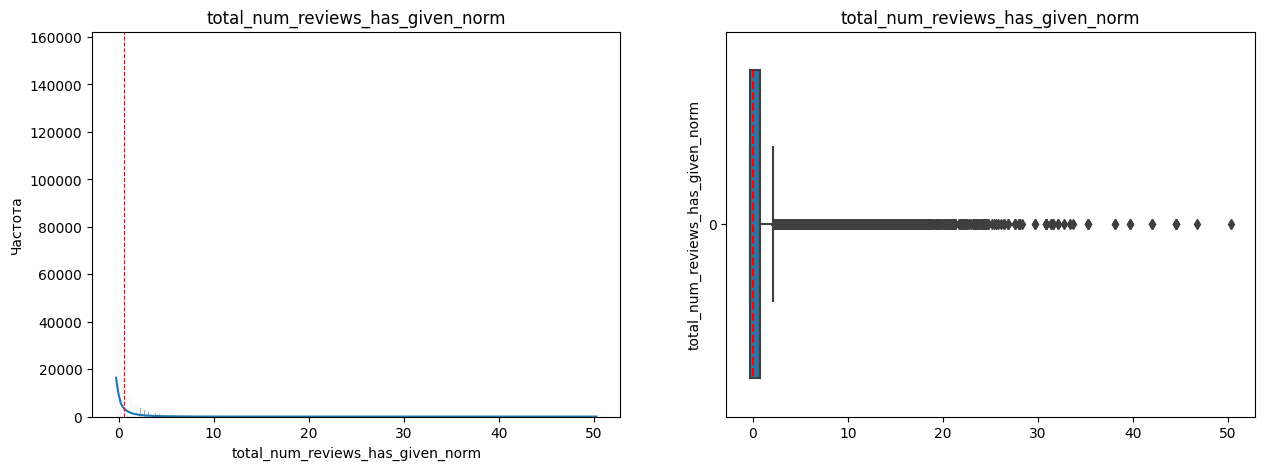

In [599]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['total_num_reviews_has_given_norm'], kde=True, ax=axes[0])

axes[0].set(xlabel='total_num_reviews_has_given_norm', ylabel='Частота')
axes[0].set_title('total_num_reviews_has_given_norm')
axes[0].axvline(data['total_num_reviews_has_given_norm'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['total_num_reviews_has_given_norm'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='total_num_reviews_has_given_norm')
axes[1].set_title('total_num_reviews_has_given_norm')

In [147]:
data = data.drop(['total_number_of_reviews_reviewer_has_given'], axis=1)

----

#### 'tags' 

In [148]:
#обработаем теги
new_tags = data['tags'].str.replace(" ']", '')
new_tags = new_tags.str.replace("[' ", '')
new_tags = new_tags.str.replace("' ", '')
new_tags = new_tags.str.replace(" '", '')


tags_a= pd.DataFrame()
tags_a['tags'] = new_tags.astype(str)

#с животными
tags_a['pet'] = tags_a['tags'].apply(lambda x: 1 if x.split(', ')[0] == 'With a pet' else 0 )
tags_a['cleaned_tags'] = tags_a['tags'].str.replace('With a pet, ', '')

#с мобильного
tags_a['device'] = tags_a['tags'].apply(lambda x: 1 if x.split(', ')[-1] == 'Submitted from a mobile device' else 0 )
tags_a['cleaned_tags'] = tags_a['cleaned_tags'].str.replace(', Submitted from a mobile device', '')

#команировка/отдых
tags_a['trip_type'] = tags_a['cleaned_tags'].apply(lambda x: x.split(', ')[0] if x.split(', ')[0] == 'Leisure trip' or x.split(', ')[0] == 'Business trip' else 'NA'  )
tags_a['cleaned_tags'] = tags_a['cleaned_tags'].str.replace('Leisure trip, ', '')
tags_a['cleaned_tags'] = tags_a['cleaned_tags'].str.replace('Business trip, ', '')

#компания
tags_a['traveler'] = tags_a['cleaned_tags'].apply(lambda x: x.split(', ')[0])
list_of_rep = ['Couple,', 'Solo traveler', 'Family with young children', 'Group',
       'Family with older children', 'Travelers with friends']

tags_a['cleaned_tags'] = tags_a['cleaned_tags'].str.replace('Couple, ', '').str.replace('Solo traveler, ', '').str.replace('Family with young children, ', '').str.replace('Solo traveler, ', '')
tags_a['cleaned_tags'] = tags_a['cleaned_tags'].str.replace('Group', '').str.replace('Group, ', '').str.replace('Family with older children, ', '').str.replace('Travelers with friends, ', '')


#срок пребывания (в строке попались некоторые ошибки, которые надо вычистить)
tags_a['duration_of_stay'] = tags_a['cleaned_tags'].apply(lambda x: x.split(', ')[-1])
#чтобы вычистить ошибки, очистим информацию и оставим только числовое значение кол-ва ночей ипользуя регулярное значение
tags_a['number_of_days'] = tags_a['duration_of_stay'].str.extract('(\d+)', expand=False)
tags_a['number_of_days'] = tags_a['number_of_days'].astype(float)
#удалим столбец с ошибками
tags_a = tags_a.drop(['duration_of_stay'], axis=1)
#удалим вспомогательный столбец cleaned_tags
tags_a = tags_a.drop(['cleaned_tags'], axis=1)
#добавим информацию о кол-ве тегов
tags_a['tags_num'] = data['tags'].str.count(',')+1

#объедим датасеты
data = pd.merge(
    data,
    tags_a,
    how="left",
    left_index=True, 
    right_index=True
)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   hotel_address                     515431 non-null  object 
 1   average_score                     515431 non-null  float64
 2   tags_x                            515431 non-null  object 
 3   days_since_review                 515431 non-null  object 
 4   lat                               512163 non-null  float64
 5   lng                               512163 non-null  float64
 6   sample                            515431 non-null  int64  
 7   reviewer_score                    515431 non-null  float64
 8   city_hotel                        515431 non-null  object 
 9   Log_total_number_of_reviews       515431 non-null  float64
 10  actuality_review                  515431 non-null  int16  
 11  month_of_review                   515431 non-null  i

Text(0, 0.5, 'reviewer_score')

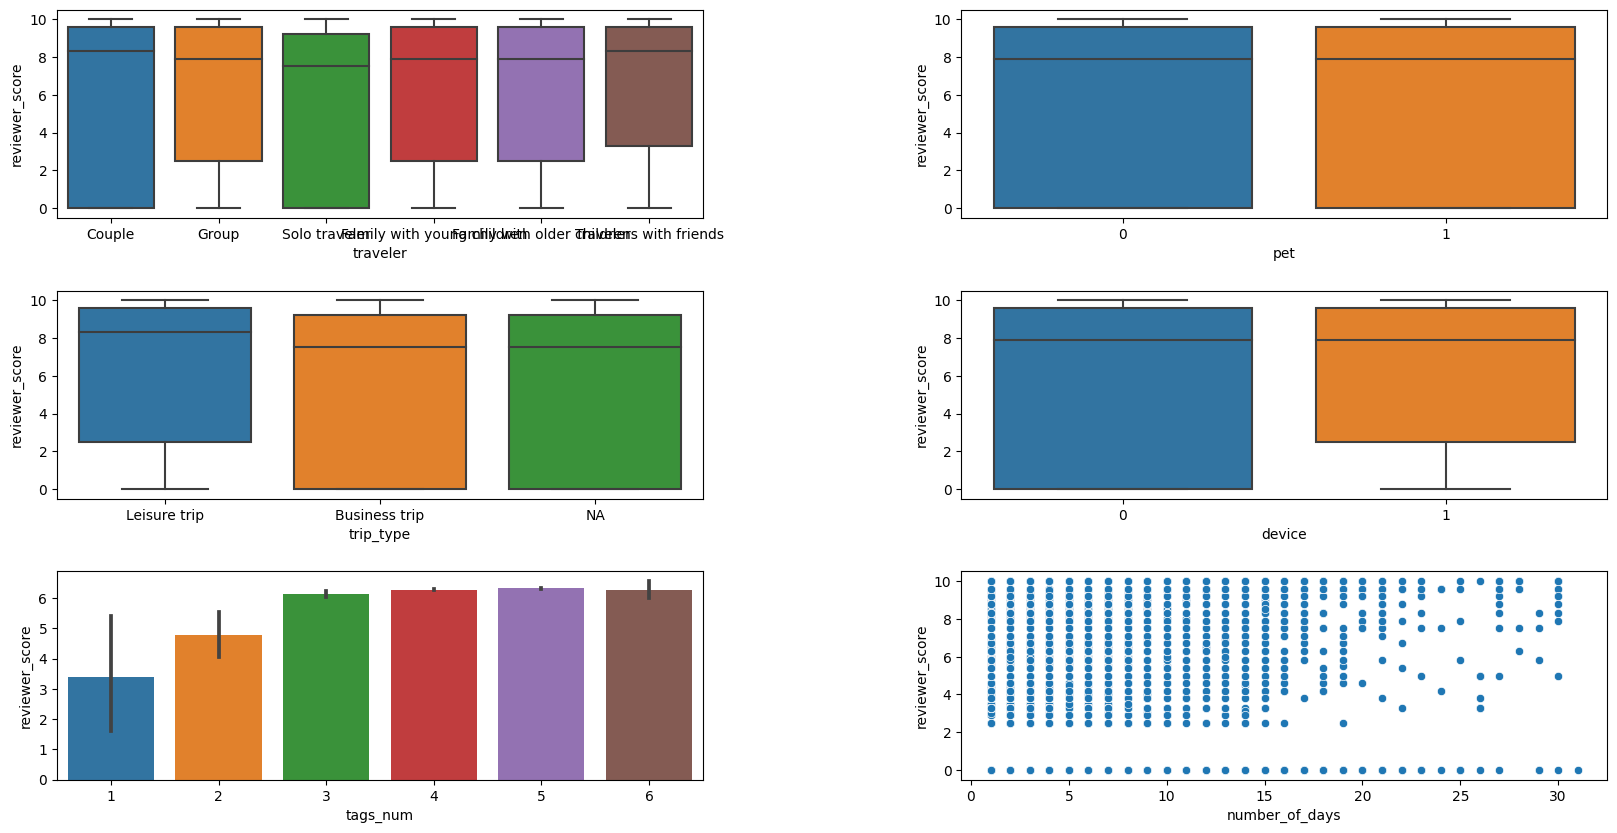

In [149]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 10))
plt.subplots_adjust(hspace=.35, wspace=.4)

boxplot1 = sns.boxplot(data=data, x="traveler", y="reviewer_score", ax=axes[0,0])
boxplot1.set_xlabel('traveler')
boxplot1.set_ylabel('reviewer_score')

boxplot2 = sns.boxplot(data=data, x="pet", y="reviewer_score", ax=axes[0,1])
boxplot2.set_xlabel('pet')
boxplot2.set_ylabel('reviewer_score')

boxplot3 = sns.boxplot(data=data, x="trip_type", y="reviewer_score", ax=axes[1,0])
boxplot3.set_xlabel('trip_type')
boxplot3.set_ylabel('reviewer_score')

boxplot4 = sns.boxplot(data=data, x="device", y="reviewer_score", ax=axes[1,1])
boxplot4.set_xlabel('device')
boxplot4.set_ylabel('reviewer_score')

barplot = sns.barplot(data=data, x="tags_num", y="reviewer_score", ax=axes[2,0])
barplot.set_xlabel('tags_num')
barplot.set_ylabel('reviewer_score')

scatterplot = sns.scatterplot(data=data, x="number_of_days", y="reviewer_score", ax=axes[2,1])
scatterplot.set_xlabel('number_of_days')
scatterplot.set_ylabel('reviewer_score')



In [150]:
data = data.drop(['tags_y','tags_x'], axis=1)

чуть подробее рассмотрим признак number_of_days

In [151]:
data['number_of_days_flag']=data['number_of_days'].apply(lambda x: x if x <= 7  else  8)

<Axes: xlabel='number_of_days_flag', ylabel='reviewer_score'>

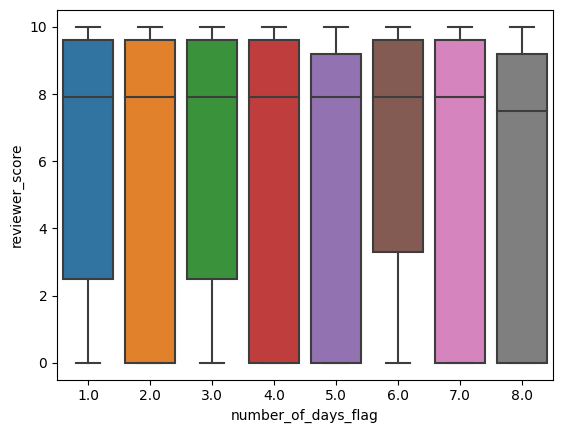

In [152]:
boxplot1 = sns.boxplot(data=data, x="number_of_days_flag", y="reviewer_score")
boxplot1

Text(0.5, 1.0, 'number_of_days')

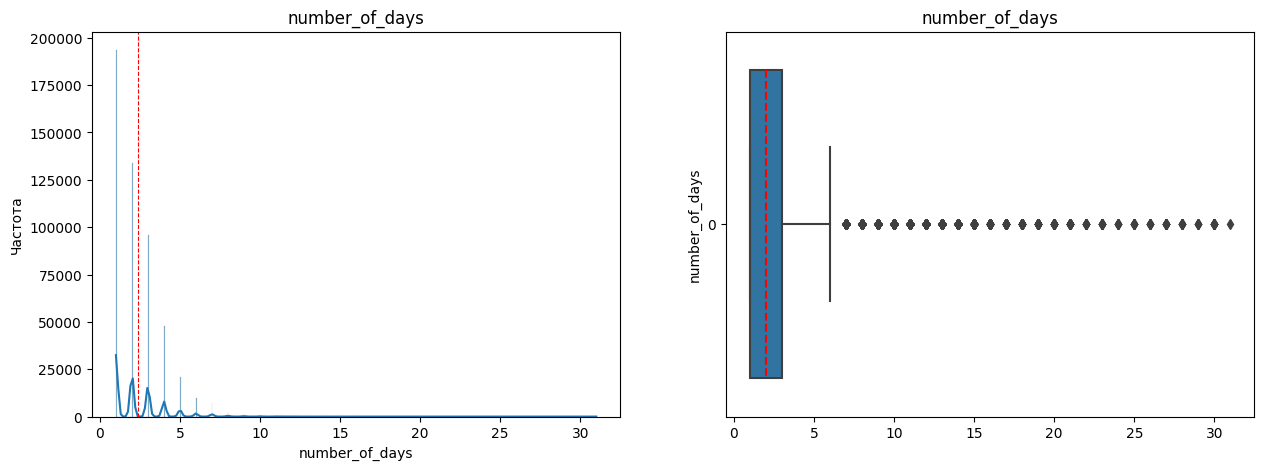

In [ ]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['number_of_days'], kde=True, ax=axes[0])

axes[0].set(xlabel='number_of_days', ylabel='Частота')
axes[0].set_title('number_of_days')
axes[0].axvline(data['number_of_days'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['number_of_days'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='number_of_days')
axes[1].set_title('number_of_days')

-----

#### 'days_since_review'

In [153]:
#оставим только цифру 
data['days_since_review_num'] =  data['days_since_review'].str.extract('(\d+)', expand=False).astype(float)

-----

#### 'lat'

In [154]:
#в данном поле есть пропуски, их необходимо обработать
print('всего таких отеля с пропусками:', data[data['lat'].isnull()]['hotel_address'].nunique())

#всего таких отеля с пропусками 17 штук, поэтому можно внести инфомрацию достаточно точно

lat = data[data['lat'].isnull()]['hotel_address'].unique() 
lng = data[data['lng'].isnull()]['hotel_address'].unique()
print('пропуски долготы и ширины совпадают:',lat == lng)

всего таких отеля с пропусками: 17
пропуски долготы и ширины совпадают: [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True]


In [155]:
# как вариант найти долготу и широту для данных адресов, я использовала сайт https://coordinates-converter.com/en/ (искала до индекса,тк в названиях улиц много ошибок)

find_lat_lng= data[data['lat'].isnull()].groupby('hotel_address').count()[['lat', 'lng']]
find_lat_lng

,lat,lng
hotel_address,,
20 Rue De La Ga t 14th arr 75014 Paris France,0,0
23 Rue Damr mont 18th arr 75018 Paris France,0,0
4 rue de la P pini re 8th arr 75008 Paris France,0,0
Bail n 4 6 Eixample 08010 Barcelona Spain,0,0
Gr nentorgasse 30 09 Alsergrund 1090 Vienna Austria,0,0
Hasenauerstra e 12 19 D bling 1190 Vienna Austria,0,0
Josefst dter Stra e 10 12 08 Josefstadt 1080 Vienna Austria,0,0
Josefst dter Stra e 22 08 Josefstadt 1080 Vienna Austria,0,0
Landstra er G rtel 5 03 Landstra e 1030 Vienna Austria,0,0


In [156]:

lat_lng = [[48.85889, 2.320041],
           [48.853495, 2.348391],
           [48.85889, 2.320041],
           [41.382894, 2.177432],
           
           [48.225073, 16.358398],
           [48.208354, 16.372504],
           [48.210852, 16.34736],
           [48.210852, 16.34736],
           [48.208354, 16.372504],
           [48.163109,16.458013],
           
           [41.393689,2.163655],
           
           [48.214955,16.302153],
           
           [41.393689,2.163655],
           
           [48.208354,16.372504],
           [48.200638,16.426895],
           [48.225073,16.426895],
           [48.225073,16.426895]]

In [157]:
for i in range (17):
    find_lat_lng.iloc[i] = lat_lng[i]
find_lat_lng

data = data.set_index('hotel_address')
data.update(find_lat_lng)
data = data.reset_index()



In [158]:
#создадим признак, который будет оценивать удаленность отеля от центра города

#центры городов

info = [
['Paris', 48.85341, 2.3488],
['Milan', 45.46427, 9.18951],
['Amsterdam', 52.37403, 4.88969],
['Barcelona', 41.38879, 2.15899],
['London', 51.50853, -0.12574],
['Vienna', 48.20849, 16.37208],
]

city_centers = pd.DataFrame(info, columns=['City', 'City_lat','City_lng']) 


data = data.merge(city_centers[['City_lat','City_lng']], left_on='city_hotel', right_on=city_centers['City'], how = 'left')

In [159]:
# c помощью пакета geopy  сделаем расчет дистанции и сохраним как новый признак

from geopy.distance import geodesic

def distancer(row):
    
    coords_1 = (row['lat'], row['lng'])
    coords_2 = (row['City_lat'], row['City_lng'])
    a = geodesic(coords_1, coords_2).km
    return a

data['distance_to_center'] = data.apply(distancer, axis=1)



Text(0.5, 1.0, 'distance_to_center')

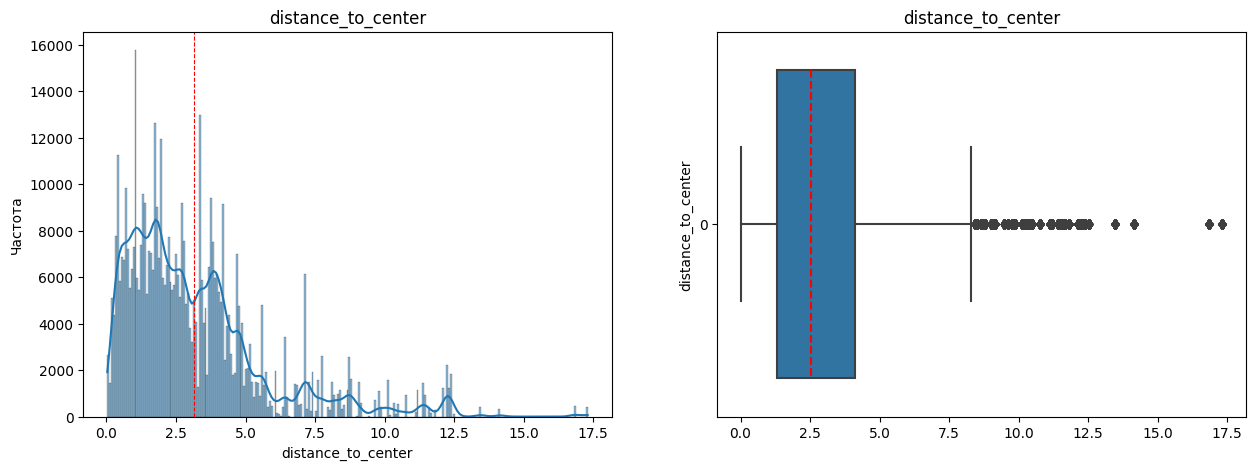

In [160]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['distance_to_center'], kde=True, ax=axes[0])

axes[0].set(xlabel='distance_to_center', ylabel='Частота')
axes[0].set_title('distance_to_center')
axes[0].axvline(data['distance_to_center'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['distance_to_center'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='distance_to_center')
axes[1].set_title('distance_to_center')

In [163]:
data = data.drop(['City_lat','City_lng'], axis=1)

----

____

# Очистка данных повторная, после добавления признаков

In [161]:
#проверка на наличие пропусков
cols_null_percent = data.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

number_of_days    0.03725
dtype: float64

In [162]:
#заменим отсутствующие означения на моду

#создаём словарь 'имя_столбца': число (признак), на который надо заменить пропуски 
values = {
    'number_of_days': data['number_of_days'].mode()[0]
    #,
    #'number_of_days_norm': data['number_of_days_norm'].mode()[0]
    
}
#заполняем оставшиеся записи константами в соответствии со словарем values
data = data.fillna(values)
#выводим результирующую долю пропусков
display(data.isnull().mean())

hotel_address                       0.0
average_score                       0.0
days_since_review                   0.0
lat                                 0.0
lng                                 0.0
sample                              0.0
reviewer_score                      0.0
city_hotel                          0.0
Log_total_number_of_reviews         0.0
actuality_review                    0.0
month_of_review                     0.0
hotel_name_count                    0.0
top_hotels_flag                     0.0
top_reviewer_nationality            0.0
reviewer_from_ESC                   0.0
country_hotel_nationality           0.0
no_negative_words_flag              0.0
negative_review_clean_count         0.0
no_positive_words_flag              0.0
positive_review_clean_count         0.0
pos_neg_ratio                       0.0
positive_words_count                0.0
negative_words_count                0.0
total_num_reviews_has_given_norm    0.0
pet                                 0.0


In [164]:
#проверка на наличие неинформативных признаков

#список неинформативных признаков
low_information_cols = [] 

#цикл по всем столбцам
for col in data.columns:
    #наибольшая относительная частота в признаке
    top_freq = data[col].value_counts(normalize=True).max()
    #доля уникальных значений от размера признака
    nunique_ratio = data[col].nunique() / data[col].count()
    # сравниваем наибольшую частоту с порогом
    if top_freq > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(top_freq*100, 2)}% одинаковых значений')
    # сравниваем долю уникальных значений с порогом
    if nunique_ratio > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(nunique_ratio*100, 2)}% уникальных значений')
        
low_information_cols   

pet: 99.73% одинаковых значений


['pet']

In [165]:
#удалим неинформативный признак
data = data.drop(['pet'], axis=1)

# Подготовка признаков к моделированию

In [166]:
data_to_model = data.copy()

In [167]:
corr = data_to_model.drop(['sample','reviewer_score'], axis=1).corr(numeric_only=True)


<Axes: >

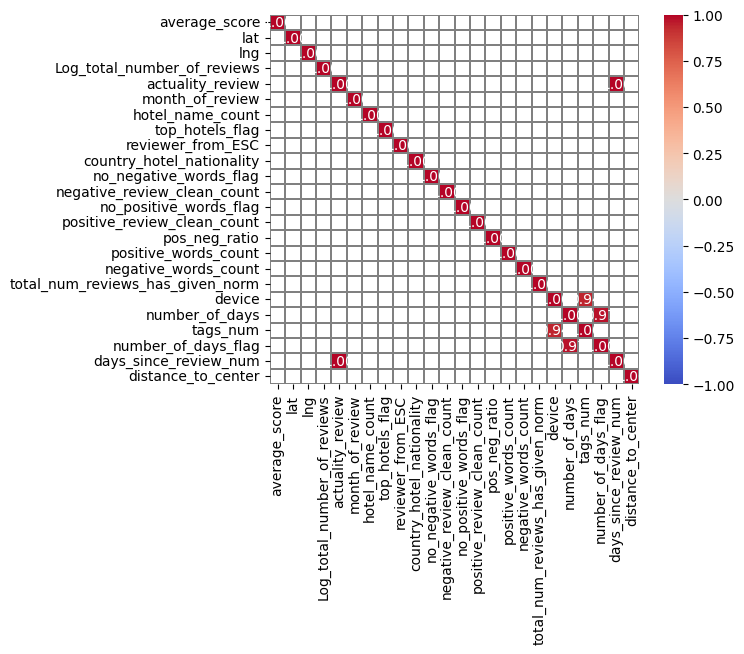

In [168]:
sns.heatmap(
    corr[corr.abs()>= 0.7], 
    vmin=-1, 
    vmax=1, 
    linewidth=0.1, 
    linecolor='gray', 
    cmap='coolwarm',
    annot = True,
    fmt='.2f',
    square=True
)


______________________________________________

In [169]:
#удалим один из пары признаков с корреляцией выше 0.70
param_to_drop =  pd.DataFrame(data_to_model.drop(['sample'], axis=1).corr(numeric_only=True).abs().unstack().sort_values(ascending=False).drop_duplicates().head(30))
param_to_drop

0
average_score               average_score                1.000000
number_of_days_flag         number_of_days               0.968906
device                      tags_num                     0.938515
positive_review_clean_count pos_neg_ratio                0.553182
positive_words_count        positive_review_clean_count  0.551121
no_negative_words_flag      pos_neg_ratio                0.546955
country_hotel_nationality   lng                          0.431423
                            number_of_days_flag          0.406671
                            lat                          0.397714
no_negative_words_flag      negative_review_clean_count  0.394635
country_hotel_nationality   number_of_days               0.383537
pos_neg_ratio               positive_words_count         0.307242
lat                         lng                          0.302579
reviewer_from_ESC           country_hotel_nationality    0.276214
country_hotel_nationality   distance_to_center           0.276009
positive_words_count        no_positive_words_flag       0.274517
pos_neg_ratio               negative_review_clean_count  0.238030
distance_to_center          lat                          0.229495
no_negative_words_flag      negative_words_count         0.228300
distance_to_center          lng                          0.221032
no_positive_words_flag      positive_review_clean_count  0.213023
month_of_review             actuality_review             0.210950
average_score               Log_total_number_of_reviews  0.207021
top_hotels_flag             distance_to_center           0.203472
negative_words_count        negative_review_clean_count  0.189620
number_of_days_flag         lat                          0.189477
no_negative_words_flag      no_positive_words_flag       0.182194
lat                         number_of_days               0.172788
no_negative_words_flag      average_score                0.169445
distance_to_center          average_score                0.165875

In [170]:
data_to_model = data_to_model.drop(['number_of_days','device'], axis=1)

In [329]:
#data_to_model = data_to_model.drop(['positive_words_count','total_number_of_reviews_reviewer_has_given','pos_neg_ratio',
                                    'negative_review_clean_count','number_of_days','average_score','actuality_review',
                                    'positive_review_clean_count','device','total_number_of_reviews','additional_number_of_scoring','quat_1','lat','lng', 'City_lat','City_lng'], axis=1)

In [171]:
object_columns = [col for col in data_to_model.columns
    if ((data_to_model[col].dtypes == 'object') | \
        (data_to_model[col].dtype.name == 'category'))]


# смотрим, что можем закодировать

object_columns

['hotel_address',
 'days_since_review',
 'city_hotel',
 'top_reviewer_nationality',
 'trip_type',
 'traveler']

In [172]:
#закодируем категориальные признаки

import category_encoders as ce # импорт для работы с кодировщиком

encoder = ce.OneHotEncoder(cols=['city_hotel','traveler','trip_type','top_reviewer_nationality'] ) # указываем столбец для кодирования
type_bin = encoder.fit_transform(data_to_model[['city_hotel','traveler','trip_type','top_reviewer_nationality']])
data_to_model = pd.concat([data_to_model, type_bin], axis=1)

In [173]:
data_to_model = data_to_model.drop(['city_hotel','traveler','trip_type','top_reviewer_nationality'], axis=1)

<Axes: >

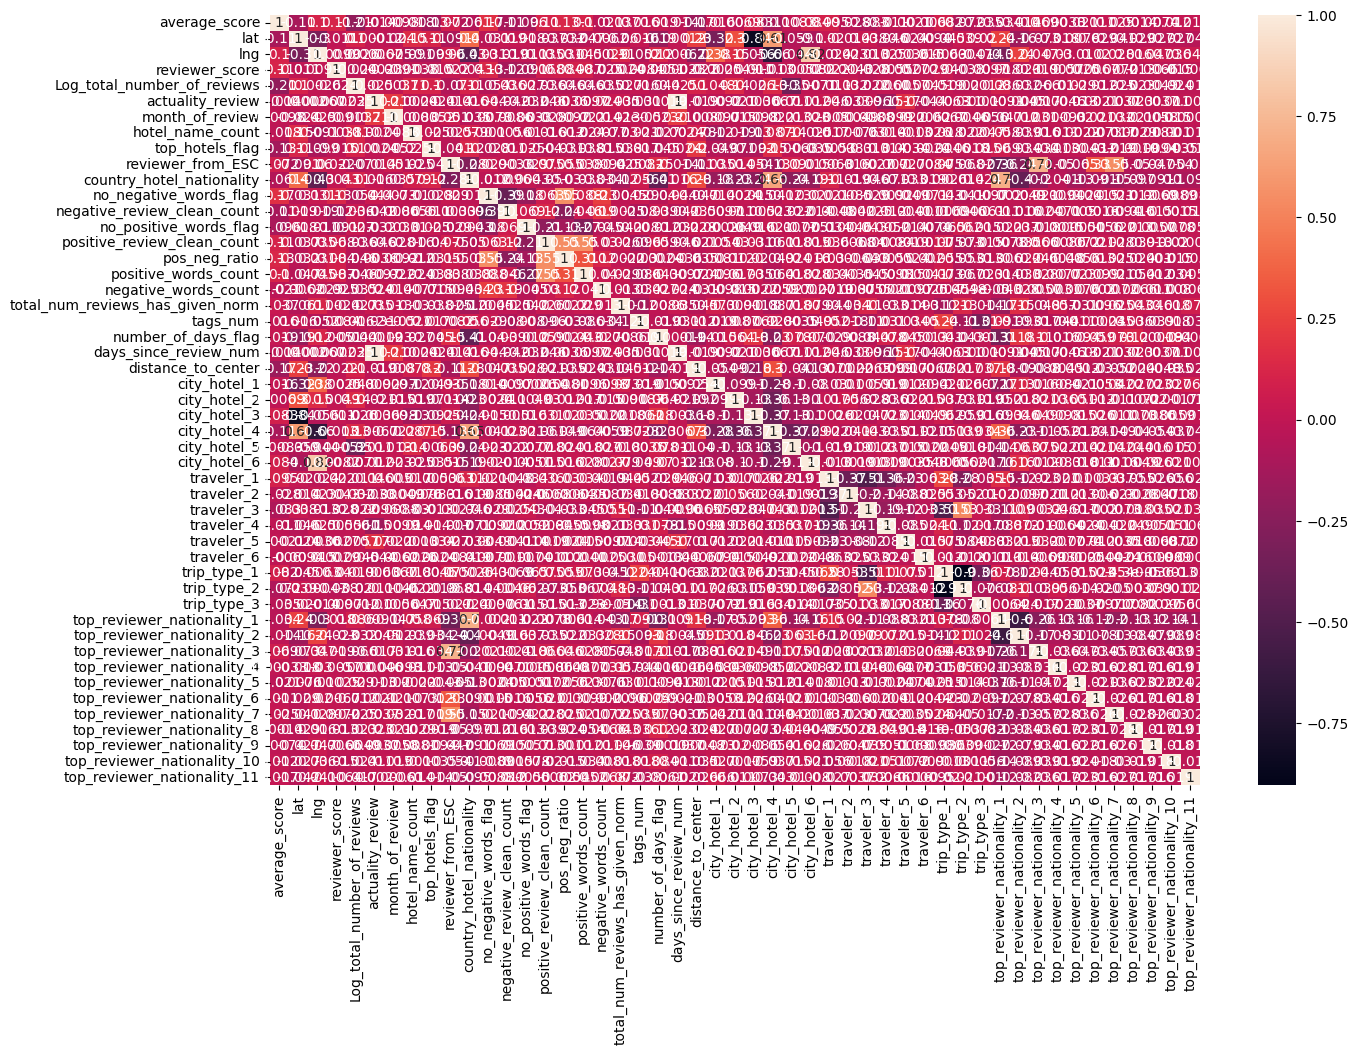

In [174]:
plt.rcParams['figure.figsize'] = (15,10)
sns.heatmap(data_to_model.drop(['sample'], axis=1).corr(numeric_only=True), annot=True)

In [175]:

#удалим один из пары признаков с корреляцией выше 0.70
param_to_drop1 =  pd.DataFrame(data_to_model.drop(['sample'], axis=1).corr(numeric_only=True).abs().unstack().sort_values(ascending=False).drop_duplicates().head(30))
param_to_drop1

0
average_score               average_score                1.000000
trip_type_2                 trip_type_1                  0.904047
lat                         city_hotel_3                 0.844686
city_hotel_6                lng                          0.824958
top_reviewer_nationality_3  reviewer_from_ESC            0.715135
top_reviewer_nationality_1  country_hotel_nationality    0.700668
city_hotel_4                lng                          0.661208
                            country_hotel_nationality    0.651570
                            lat                          0.611146
top_reviewer_nationality_1  top_reviewer_nationality_2   0.598635
positive_review_clean_count pos_neg_ratio                0.553182
top_reviewer_nationality_7  reviewer_from_ESC            0.551677
positive_review_clean_count positive_words_count         0.551121
no_negative_words_flag      pos_neg_ratio                0.546955
trip_type_2                 traveler_3                   0.528530
traveler_3                  trip_type_1                  0.509046
                            traveler_1                   0.505215
lng                         country_hotel_nationality    0.431423
country_hotel_nationality   number_of_days_flag          0.406671
                            top_reviewer_nationality_2   0.402929
lat                         country_hotel_nationality    0.397714
no_negative_words_flag      negative_review_clean_count  0.394635
lng                         city_hotel_1                 0.376223
traveler_2                  traveler_1                   0.372908
city_hotel_4                city_hotel_3                 0.369999
city_hotel_5                city_hotel_4                 0.368175
reviewer_from_ESC           top_reviewer_nationality_1   0.361615
city_hotel_4                city_hotel_2                 0.359694
traveler_1                  traveler_4                   0.358483
trip_type_1                 trip_type_3                  0.357668

In [176]:
data_to_model = data_to_model.drop(['trip_type_2','city_hotel_3',
                                    'city_hotel_6','top_reviewer_nationality_3','top_reviewer_nationality_1'], axis=1)

In [390]:
#data_to_model = data_to_model.drop(['number_of_days','device','review_year','trip_type_2'], axis=1)

In [177]:
object_columns = [col for col in data_to_model.columns
    if ((data_to_model[col].dtypes == 'object') | \
        (data_to_model[col].dtype.name == 'category') | \
        (data_to_model[col].dtypes == 'datetime64[ns]'))]

# смотрим, что попадает под удаление
print(f'Удалению подлежит {len(object_columns)} столбцов с нечисловыми данными:')
object_columns

Удалению подлежит 2 столбцов с нечисловыми данными:


['hotel_address', 'days_since_review']

In [178]:
# убираем признаки которые еще не успели обработать, 
# модель на признаках с dtypes "object" обучаться не будет, просто выберим их и удалим
data_to_model.drop(object_columns, axis = 1, inplace=True)

In [645]:
data_to_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 46 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                515431 non-null  int64  
 1   average_score                               515431 non-null  float64
 2   total_number_of_reviews_reviewer_has_given  515431 non-null  int64  
 3   sample                                      515431 non-null  int64  
 4   reviewer_score                              515431 non-null  float64
 5   actuality_review                            515431 non-null  int16  
 6   review_year                                 515431 non-null  int32  
 7   review_day                                  515431 non-null  int32  
 8   weekday                                     515431 non-null  int32  
 9   month_of_review                             515431 non-null  int32  
 

_____________

#  Моделирование

In [179]:
data_to_model_ready = data_to_model.copy()

In [729]:
data_to_model_ready = data_to_model_ready.drop([ 'review_day', 'weekday','traveler_6','weekday', 'top_reviewer_nationality_5',
                                                'traveler_5','city_hotel_5','top_reviewer_nationality_6',
                                                'city_hotel_1','traveler_2','hotel_name_count','total_number_of_reviews_reviewer_has_given'], axis=1)

In [ ]:
#удалим незначимые признаки  

In [180]:
# Теперь выделим тестовую часть
train_data = data_to_model_ready.query('sample == 1').drop(['sample'], axis=1)
test_data = data_to_model_ready.query('sample == 0').drop(['sample'], axis=1)

y = train_data.reviewer_score.values            # наш таргет
X = train_data.drop(['reviewer_score'], axis=1)

________________________

## Оценка значимости каждого признака для целевой переменной — рейтинг отеля
#### Для оценки значимости категориальных признаков будем использовать тест хи-квадрат, для непрерывных признаков — тест ANOVA.

In [181]:
data_to_model_ready.columns

Index(['average_score', 'lat', 'lng', 'sample', 'reviewer_score',
       'Log_total_number_of_reviews', 'actuality_review', 'month_of_review',
       'hotel_name_count', 'top_hotels_flag', 'reviewer_from_ESC',
       'country_hotel_nationality', 'no_negative_words_flag',
       'negative_review_clean_count', 'no_positive_words_flag',
       'positive_review_clean_count', 'pos_neg_ratio', 'positive_words_count',
       'negative_words_count', 'total_num_reviews_has_given_norm', 'tags_num',
       'number_of_days_flag', 'days_since_review_num', 'distance_to_center',
       'city_hotel_1', 'city_hotel_2', 'city_hotel_4', 'city_hotel_5',
       'traveler_1', 'traveler_2', 'traveler_3', 'traveler_4', 'traveler_5',
       'traveler_6', 'trip_type_1', 'trip_type_3',
       'top_reviewer_nationality_2', 'top_reviewer_nationality_4',
       'top_reviewer_nationality_5', 'top_reviewer_nationality_6',
       'top_reviewer_nationality_7', 'top_reviewer_nationality_8',
       'top_reviewer_national

In [182]:
# непрерывные признаки
num_cols = ['average_score', 'lat', 'lng', 'Log_total_number_of_reviews', 'actuality_review', 'month_of_review',
       'hotel_name_count','negative_review_clean_count', 'positive_review_clean_count', 'pos_neg_ratio', 'positive_words_count',
       'negative_words_count', 'total_num_reviews_has_given_norm', 'tags_num','days_since_review_num', 'distance_to_center'
]

# категориальные признаки
cat_cols = [ 'top_hotels_flag', 'reviewer_from_ESC',
       'country_hotel_nationality', 'no_negative_words_flag',
       'no_positive_words_flag','number_of_days_flag',
       
       'city_hotel_1', 'city_hotel_2', 'city_hotel_4', 'city_hotel_5',
       'traveler_1', 'traveler_2', 'traveler_3', 'traveler_4', 'traveler_5',
       'traveler_6', 'trip_type_1', 'trip_type_3',
       'top_reviewer_nationality_2', 'top_reviewer_nationality_4',
       'top_reviewer_nationality_5', 'top_reviewer_nationality_6',
       'top_reviewer_nationality_7', 'top_reviewer_nationality_8',
       'top_reviewer_nationality_9', 'top_reviewer_nationality_10',
       'top_reviewer_nationality_11']

<Axes: >

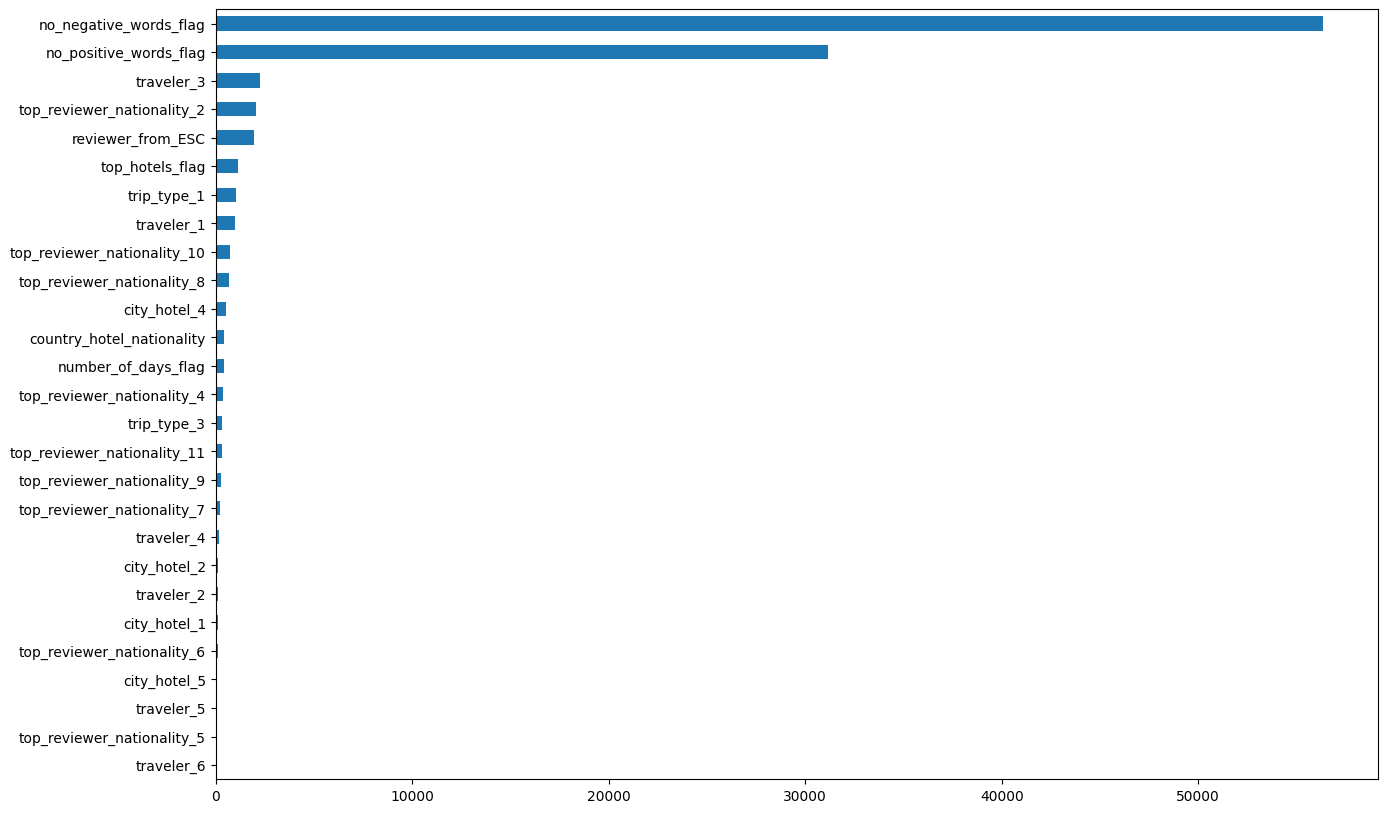

In [183]:
#Для оценки значимости категориальных переменных будем использовать изученный нами непараметрический тест хи-квадрат, реализованный в библиотеке sklearn.feature_selection.chi2.
y=y.astype('int')


from sklearn.feature_selection import chi2 # хи-квадрат

imp_cat = pd.Series(chi2(X[cat_cols], y)[0], index=cat_cols)
imp_cat.sort_values(inplace = True)
imp_cat.plot(kind = 'barh')

<Axes: >

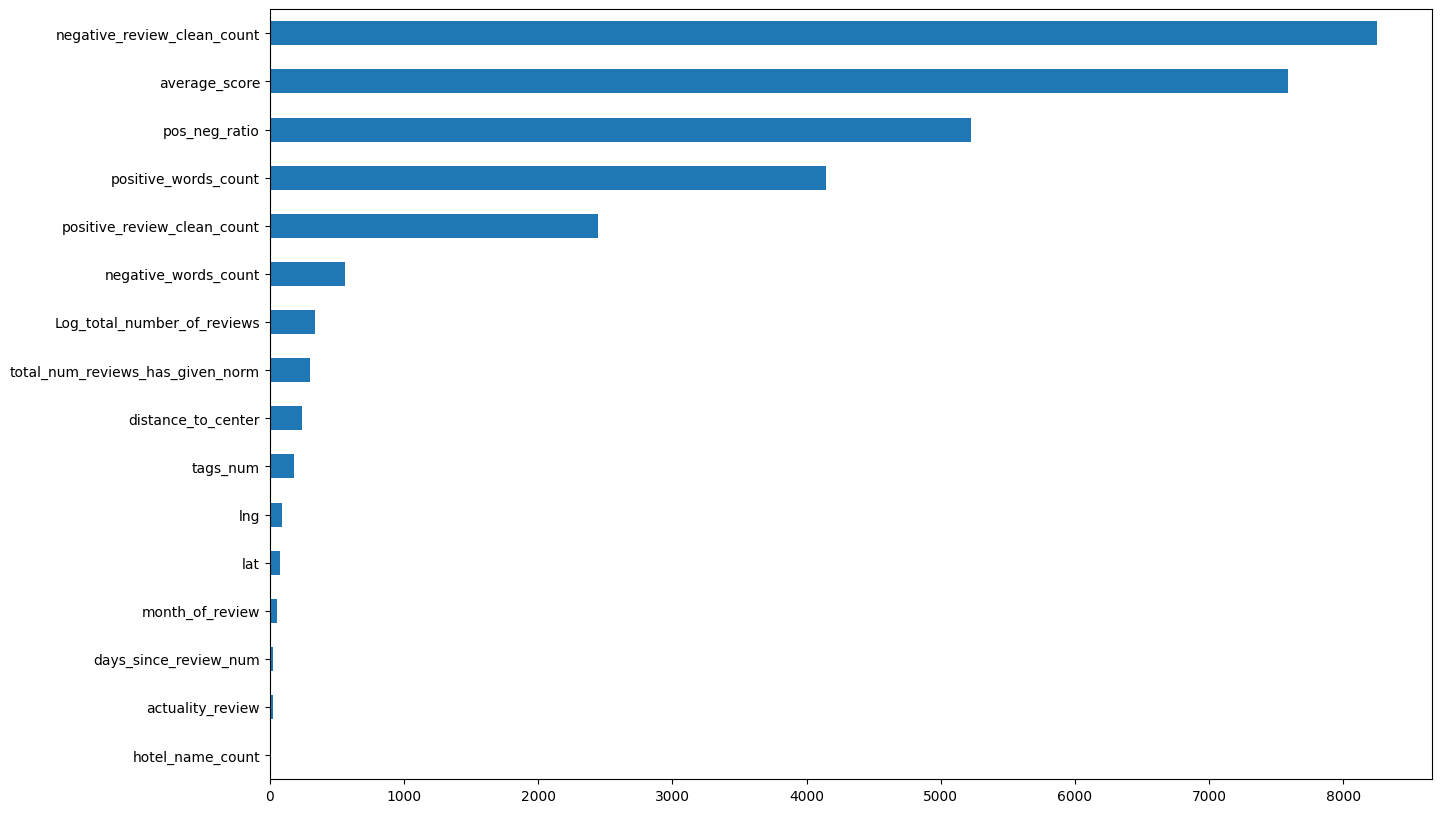

In [184]:
#Для оценки значимости непрерывных переменных будем использовать функцию f_classif из библиотеки sklearn

from sklearn.feature_selection import f_classif # anova

imp_num = pd.Series(f_classif(X[num_cols], y)[0], index = num_cols)
imp_num.sort_values(inplace = True)
imp_num.plot(kind = 'barh')

In [185]:
# Воспользуемся специальной функцие train_test_split для разбивки тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [186]:
# проверяем
test_data.shape, train_data.shape, X.shape, X_train.shape, X_test.shape

((128935, 44), (386496, 44), (386496, 43), (309196, 43), (77300, 43))

In [188]:
# Импортируем необходимые библиотеки:
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели
from sklearn import metrics # инструменты для оценки точности модели

In [189]:
# Создаём модель (НАСТРОЙКИ НЕ ТРОГАЕМ)
model = RandomForestRegressor(n_estimators=100, verbose=1, n_jobs=-1, random_state=RANDOM_SEED)

In [190]:
# Обучаем модель на тестовом наборе данных
model.fit(X_train, y_train)

# Используем обученную модель для предсказания рейтинга ресторанов в тестовой выборке.
# Предсказанные значения записываем в переменную y_pred
y_pred = model.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.4min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.6s finished


In [191]:
params={"random_state":RANDOM_SEED,
        "model_type": 'model'
}
experiment.log_parameters(params)

In [ ]:
#experiment.log_confusion_matrix(y_test.tolist(), y_pred.tolist())

In [192]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они в среднем отличаются
# Метрика называется Mean Absolute Error (MAE) и показывает среднее отклонение предсказанных значений от фактических.
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений в отношении фактических. 
print(
    'MAE:', round(metrics.mean_absolute_error(y_test, y_pred),5),
    'MAPE:', round(metrics.mean_absolute_percentage_error(y_test, y_pred),5))

MAE: 1.00969 MAPE: 0.15511


In [193]:
MAPE = metrics.mean_absolute_error(y_test, y_pred)
MAE = metrics.mean_absolute_error(y_test, y_pred)
metrics = {"MAPE":MAPE,
           "MAE":MAE
           }
experiment.log_metrics(metrics)

Комментарии к метрикам оценки качества:

стартовая MAPE 0.14136595874382513

1) MAE: 0.98231 MAPE: 0.14136 стартовая модель бейзлайна
2) MAE: 0.98469 MAPE: 0.14197 удалила дубликаты, добавила признак Log_total_number_of_reviews, удалила lat,lng, забыла удалить признак total_number_of_reviews
3) MAE: 0.98483 MAPE: 0.14197 удалила признак total_number_of_reviews
4) MAE: 0.97925 MAPE: 0.14119 вернула lat,lng, заменила пропуски на 0
5) MAE: 0.9797 MAPE: 0.14126 добавила категориальные признаки страна и город нахождения отеля
6) MAE: 0.98013 MAPE: 0.14133 оставила только признак города нахождения отеля
7) MAE: 0.93958 MAPE: 0.13576 добавила кучу признаков с учетом анализа отзывов
8) MAE: 0.93595 MAPE: 0.13527 исключила все категориальные, добавила числовые из тегов,забыла удалить num_0f_days
9) MAE: 0.93564 MAPE: 0.13522 удалила num_0f_days
10) MAE: 0.92367 MAPE: 0.1332 добавила признак кол-во позитивных слов
11) MAE: 0.92365 MAPE: 0.13318 вернула категориальные
12) MAE: 0.92321 MAPE: 0.13313 обновила замену пропусков lat, lng на точные, нормализовала
13) MAE: 0.92455 MAPE: 0.13331 добавлен новый показатель - близость отеля к центру города
14) MAE: 0.91827 MAPE: 0.1324 снесла всю нормализацию добавила дамми путешенственник и тип путешествия
15) MAE: 0.91596 MAPE: 0.13212
16) MAE: 1.01452 MAPE: 0.15582 хехе
17) MAE: 0.9172 MAPE: 0.13234
18) MAE: 1.00969 MAPE: 0.15511 все стало супер хуже

{'web': 'https://www.comet.com/api/image/download?imageId=83acea06534f41b98b7ccf2ad074eeb5&experimentKey=9a164f66667444d1b14536c490654e91',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=83acea06534f41b98b7ccf2ad074eeb5&experimentKey=9a164f66667444d1b14536c490654e91',
 'imageId': '83acea06534f41b98b7ccf2ad074eeb5'}

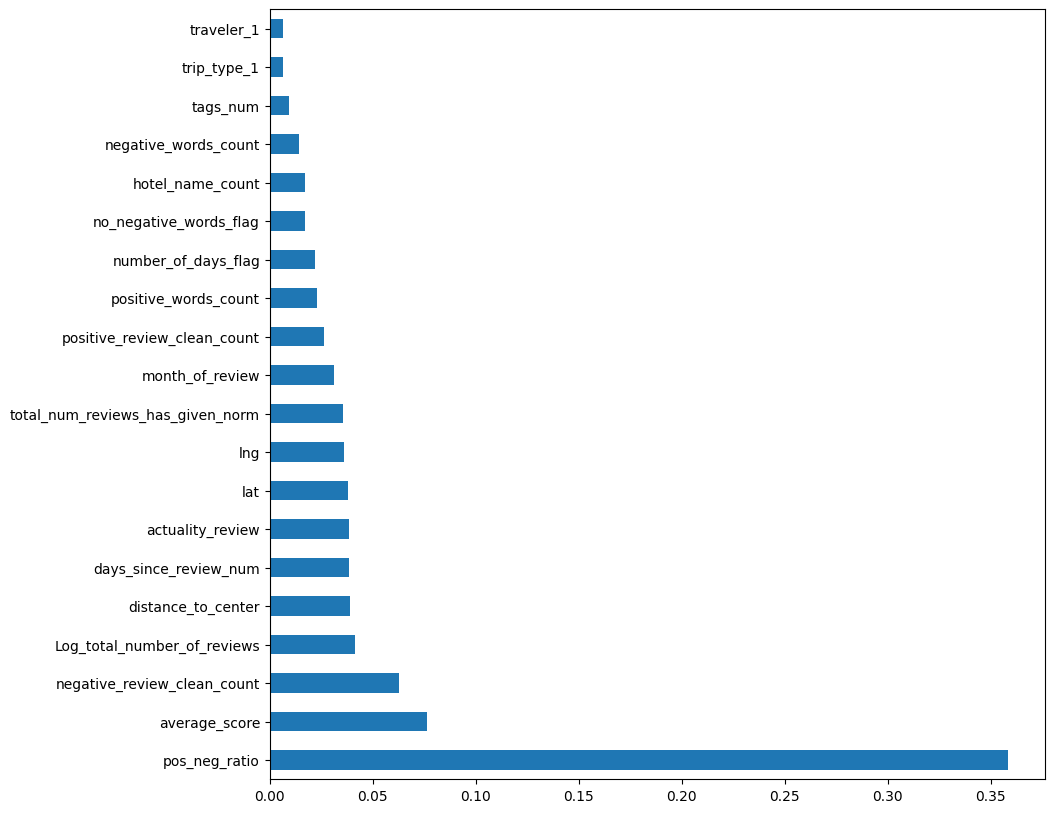

In [194]:
# в RandomForestRegressor есть возможность вывести самые важные признаки для модели
plt.rcParams['figure.figsize'] = (10,10)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
experiment.log_figure(feat_importances)


In [32]:
test_data.sample(10)

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score
66285,601,8.5,55,4032,48,14,0.0
103970,137,7.9,33,966,12,1,0.0
105697,252,8.1,50,1600,9,10,0.0
18312,98,7.4,37,597,24,6,0.0
86463,457,6.8,9,2751,5,11,0.0
53781,237,8.3,7,2372,19,1,0.0
60607,390,7.8,48,1717,18,3,0.0
20134,509,8.4,14,1560,9,19,0.0
33021,231,8.9,14,857,39,17,0.0
86171,690,8.6,17,2890,3,1,0.0


In [33]:
test_data = test_data.drop(['reviewer_score'], axis=1)

In [34]:
sample_submission

,reviewer_score,id
0,8.502000,488440
1,8.080000,274649
2,7.968000,374688
3,9.524000,404352
4,9.419464,451596
...,...,...
128930,9.120000,495812
128931,5.740000,315577
128932,8.430000,511968
128933,9.617000,303386


In [35]:
predict_submission = model.predict(test_data)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.1s finished


In [36]:
predict_submission

array([8.502 , 8.08  , 7.968 , ..., 8.43  , 9.617 , 7.9375])

In [37]:
list(sample_submission)

['reviewer_score', 'id']

In [38]:
sample_submission['reviewer_score'] = predict_submission
sample_submission.to_csv('submission.csv', index=False)
sample_submission.head(10)

,reviewer_score,id
0,8.502000,488440
1,8.080000,274649
2,7.968000,374688
3,9.524000,404352
4,9.419464,451596
5,8.833000,302161
6,6.802000,317079
7,7.822000,13963
8,9.133000,159785
9,8.108000,195089
